In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install torch-geometric torch-scatter torch-sparse
!pip install --upgrade numpy joblib scikit-learn pandas scipy matplotlib seaborn networkx xgboost 
!pip install imbalanced-learn
!pip install jupyter jupyterlab ipykernel
!pip install tqdm
!pip install shap>=0.43.0
!pip install numba==0.59.1
!pip install llvmlite==0.43.0

Looking in indexes: https://download.pytorch.org/whl/cpu



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\CB\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached torch_scatter-2.1.2.tar.gz (108 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached torch_sparse-0.6.18.tar.gz (209 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for torch-scatter
  Running setup.py clean for torch-sparse
Failed to build torch-scatter torch-sparse


  DEPRECATION: Building 'torch-scatter' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'torch-scatter'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [43 lines of output]
      C:\Users\CB\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\setuptools\dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the f

^C



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\CB\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\CB\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\CB\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


^C


In [ ]:
# Re-Install PyTorch Geometric with pre-built wheels

!pip install torch-geometric --no-build-isolation
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch_2.8.0+cpu.html


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\CB\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Looking in links: https://data.pyg.org/whl/torch_2.8.0+cpu.html


ERROR: Could not find a version that satisfies the requirement torch-scatter (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\CB\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch-scatter


In [ ]:
import time
import torch
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import torch.nn as nn
import xgboost as xgb
import networkx as nx
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch_geometric.data import Data
import torch_geometric.transforms as T
from imblearn.over_sampling import SMOTE
from torch_geometric.utils import from_networkx
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch_geometric.nn import SAGEConv, GCNConv, GATConv, global_mean_pool
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, precision_recall_curve, recall_score, f1_score, average_precision_score, matthews_corrcoef,roc_curve




warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")




In [ ]:
# Load the datasets
DATA_DIR = './dataset/rawData/elliptic_bitcoin_dataset' 

with tqdm(total=3, desc="Loading CSV files", unit="file") as pbar:
    elliptic_txs_classes = pd.read_csv(f'{DATA_DIR}/elliptic_txs_classes.csv')
    pbar.update(1)
    
    elliptic_txs_edgelist = pd.read_csv(f'{DATA_DIR}/elliptic_txs_edgelist.csv')
    pbar.update(1)
    
    elliptic_txs_features = pd.read_csv(f'{DATA_DIR}/elliptic_txs_features.csv')
    pbar.update(1)

print("Datasets loaded successfully")


Loading CSV files: 100%|██████████| 3/3 [00:18<00:00,  6.20s/file]

Datasets loaded successfully


**Data Analysis**

In [ ]:
# Label mapping
label_map = {'2': 0, '1': 1}

#Rename columns for clarity
elliptic_txs_classes.columns = ["node_ID","class_label"]
elliptic_txs_features.columns= ['node_ID', 'time_step'] + [f'feature_{i}' for i in range(1,166)]

#Merge features and classes datasets
data= elliptic_txs_features.merge(elliptic_txs_classes, on='node_ID', how= 'left')

# Examine the merged dataset structure
print(f"Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data.head()

Shape: (203768, 168)
Columns: ['node_ID', 'time_step', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'f

,node_ID,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class_label
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540,unknown


In [ ]:
#Check class distribution
data['class_label'].value_counts()


class_label
unknown    157204
2           42019
1            4545
Name: count, dtype: int64

In [ ]:
#Check to know how many transactions we have in the dataset
print(f"Number of edges in the transaction network: {len(elliptic_txs_edgelist)}")
print(f"Shape of dataset: {data.shape}")

Number of edges in the transaction network: 234355
Shape of dataset: (203768, 168)


In [ ]:
#Check detailed class distribution with percentages
class_counts= data['class_label'].value_counts()
class_percentages= data['class_label'].value_counts(normalize=True) * 100

print("Class Distribution:")

for class_label, count in class_counts.items():
    percentage = class_percentages[class_label]
    print(f"{class_label}: {count} transactions ({percentage:.2f}%)")


Class Distribution:
unknown: 157204 transactions (77.15%)
2: 42019 transactions (20.62%)
1: 4545 transactions (2.23%)


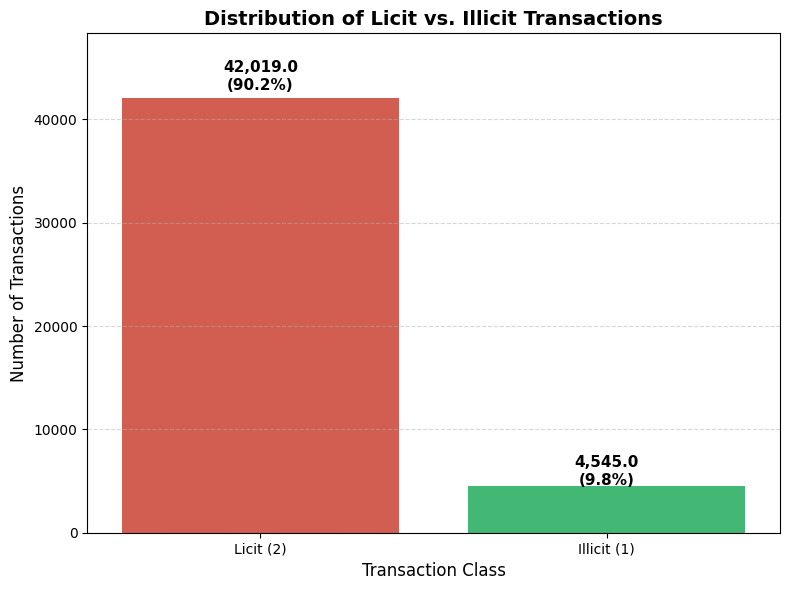

In [ ]:
# 1. Filter only labelled data (Class 1 = Illicit, Class 2 = Licit)
labelled_data = data[data['class_label'].isin(['1', '2'])].copy()

# 2. Count the values
class_counts = labelled_data['class_label'].value_counts().rename(index={'1': 'Illicit (1)', '2': 'Licit (2)'})
percentages = labelled_data['class_label'].value_counts(normalize=True) * 100

# 3. Create the Bar Chart with adjusted height
plt.figure(figsize=(8, 6))  # Increased height from 5 to 6
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#e74c3c', '#2ecc71'])

# 4. Add labels on top of bars with dynamic positioning
for i, p in enumerate(ax.patches):
    height = p.get_height()
    # Dynamic offset: use 2% of the bar height instead of fixed 1000
    offset = height * 0.02
    ax.text(p.get_x() + p.get_width() / 2., height + offset,
            f'{height:,}\n({percentages.iloc[i]:.1f}%)',
            ha="center", fontsize=11, fontweight='bold')

# 5. Formatting with adjusted y-axis limits
plt.title('Distribution of Licit vs. Illicit Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Class', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Automatically adjust y-axis to fit labels (adds 10% padding at top)
plt.ylim(0, class_counts.max() * 1.15)

plt.tight_layout()  # Prevents label cutoff
plt.show()

In [ ]:
# Examine the edgelist (transaction network)
elliptic_txs_edgelist.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [ ]:
#Check for missing values
missing_values = data.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")
print(f"Columns with missing values: {missing_values[missing_values > 0]}")


Total missing values: 0
Columns with missing values: Series([], dtype: int64)


In [ ]:
# Basic statistics for features
data[['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']].describe()


,feature_1,feature_2,feature_3,feature_4,feature_5
count,2.037680e+05,2.037680e+05,203768.000000,2.037680e+05,2.037680e+05
mean,8.414927e-07,9.062637e-07,0.000006,5.985709e-07,2.153162e-07
std,1.000005e+00,1.000005e+00,1.000001,1.000005e+00,1.000005e+00
min,-1.729826e-01,-2.105526e-01,-1.756361,-1.219696e-01,-6.372457e-02
25%,-1.725317e-01,-1.803266e-01,-1.201369,-1.219696e-01,-4.387455e-02
50%,-1.692045e-01,-1.328975e-01,0.463609,-1.219696e-01,-4.387455e-02
75%,-1.318532e-01,-5.524241e-02,1.018602,-1.219696e-01,-4.387455e-02
max,7.168197e+01,7.359505e+01,2.683580,4.902760e+01,2.600907e+02


In [ ]:
# Analyze temporal distribution
print(f"Time steps range: {data['time_step'].min()} to {data['time_step'].max()}")
print(f"Number of unique time steps: {data['time_step'].nunique()}")
print(f"Transactions per time step:")
time_dist = data['time_step'].value_counts().sort_index()
print(time_dist.head(10))

Time steps range: 1 to 49
Number of unique time steps: 49
Transactions per time step:
time_step
1     7879
2     4544
3     6621
4     5693
5     6803
6     4328
7     6048
8     4457
9     4996
10    6727
Name: count, dtype: int64


In [ ]:
# Check feature scales and distributions
feature_stats = data[['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']].agg(['min', 'max', 'mean', 'std'])
feature_stats

,feature_1,feature_2,feature_3,feature_4,feature_5
min,-1.729826e-01,-2.105526e-01,-1.756361,-1.219696e-01,-6.372457e-02
max,7.168197e+01,7.359505e+01,2.683580,4.902760e+01,2.600907e+02
mean,8.414927e-07,9.062637e-07,0.000006,5.985709e-07,2.153162e-07
std,1.000005e+00,1.000005e+00,1.000001,1.000005e+00,1.000005e+00


In [ ]:
# Analyze class distribution over time
time_class_dist = data.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)
time_class_dist.head(10)

class_label,1,2,unknown
time_step,,,
1,17,2130,5732
2,18,1099,3427
3,11,1268,5342
4,30,1410,4253
5,8,1874,4921
6,5,480,3843
7,102,1101,4845
8,67,1098,3292
9,248,530,4218


In [ ]:
# Calculate illicit percentage by time period
time_class_percentages = data.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)

# Calculate percentages for each class
time_class_percentages['total'] = time_class_percentages.sum(axis=1)
if '1' in time_class_percentages.columns:
    time_class_percentages['illicit_percentage'] = (time_class_percentages['1'] / time_class_percentages['total']) * 100
    time_class_percentages[['illicit_percentage']].round(2)
else:
    print("No illicit transactions found (class '1' not present)")


In [ ]:
# Compare feature patterns between high and low fraud periods
high_fraud_periods = [13, 20, 9, 16, 15]
low_fraud_periods = [1, 2, 3, 5, 6]      
high_fraud_data = data[data['time_step'].isin(high_fraud_periods)]
low_fraud_data = data[data['time_step'].isin(low_fraud_periods)]

print(high_fraud_data[['feature_1', 'feature_2', 'feature_3']].mean())
print(low_fraud_data[['feature_1', 'feature_2', 'feature_3']].mean())


feature_1   -0.060535
feature_2   -0.132504
feature_3   -0.311435
dtype: float64
feature_1    0.110429
feature_2   -0.157417
feature_3   -0.879280
dtype: float64


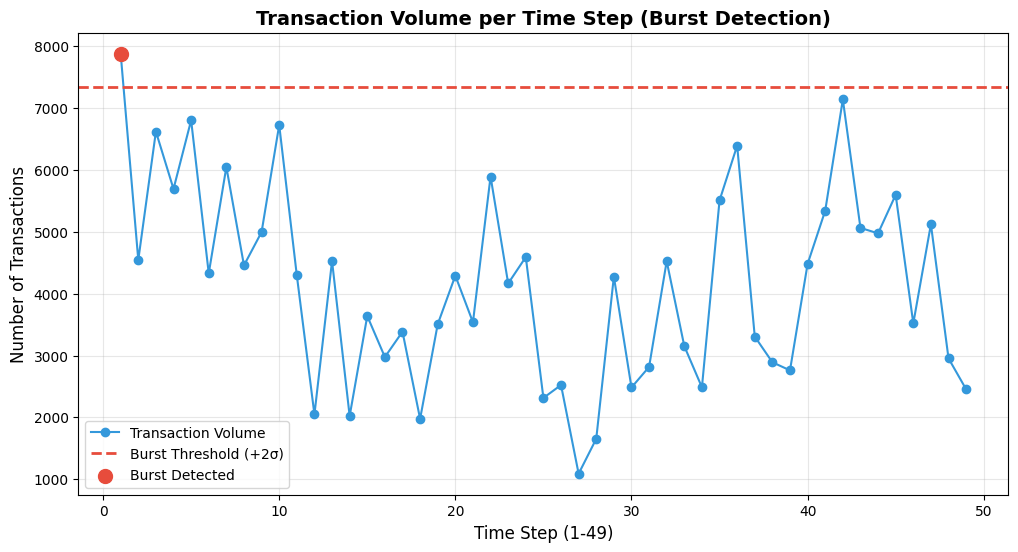

In [ ]:
# Burst Detection based on Transaction Volume

# 1. Group data by time step
tx_counts = data.groupby('time_step').size()

# 2. Calculate burst threshold (Mean + 2*StdDev)
mean_val = tx_counts.mean()
std_val = tx_counts.std()
burst_threshold = mean_val + (2 * std_val)

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.plot(tx_counts.index, tx_counts.values, marker='o', linestyle='-', color='#3498db', label='Transaction Volume')

# 4. Add the Burst Threshold Line
plt.axhline(y=burst_threshold, color='#e74c3c', linestyle='--', linewidth=2, label=f'Burst Threshold (+2σ)')

# 5. Highlight Burst Periods
burst_periods = tx_counts[tx_counts > burst_threshold]
plt.scatter(burst_periods.index, burst_periods.values, color='#e74c3c', s=100, zorder=5, label='Burst Detected')

# 6. Formatting
plt.title('Transaction Volume per Time Step (Burst Detection)', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (1-49)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Data Preprocessing**

In [ ]:
# Analyze labeled vs unlabeled data for modeling strategy
labeled_data = data[data['class_label'].isin(['1', '2'])]
unlabeled_data = data[data['class_label'] == 'unknown']
print(f"Labeled transactions: {len(labeled_data):,} ({len(labeled_data)/len(data)*100:.1f}%)")
print(f"Unlabeled transactions: {len(unlabeled_data):,} ({len(unlabeled_data)/len(data)*100:.1f}%)")


Labeled transactions: 46,564 (22.9%)
Unlabeled transactions: 157,204 (77.1%)


In [ ]:
labeled_class_dist = labeled_data['class_label'].value_counts()
labeled_class_pct = labeled_data['class_label'].value_counts(normalize=True) * 100
for class_label, count in labeled_class_dist.items():
    percentage = labeled_class_pct[class_label]
    print(f"Class {class_label}: {count:,} transactions ({percentage:.1f}%)")
    
print(f"\nClass imbalance ratio (illicit:licit): 1:{labeled_class_dist['2'] // labeled_class_dist['1']}")


Class 2: 42,019 transactions (90.2%)
Class 1: 4,545 transactions (9.8%)

Class imbalance ratio (illicit:licit): 1:9


In [ ]:
# Analyze temporal distribution of labeled data
labeled_temporal = labeled_data.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)
labeled_temporal['total_labeled'] = labeled_temporal.sum(axis=1)
labeled_temporal['illicit_pct'] = (labeled_temporal['1'] / labeled_temporal['total_labeled'] * 100).round(1)

print(labeled_temporal[['1', '2', 'total_labeled', 'illicit_pct']].head(10))

no_labels = []
for t in range(1, 50):
    if t not in labeled_temporal.index:
        no_labels.append(t)
if no_labels:
    print(f"Time steps: {no_labels}")
else:
    print("All time periods have some labeled data")


class_label    1     2  total_labeled  illicit_pct
time_step                                         
1             17  2130           2147          0.8
2             18  1099           1117          1.6
3             11  1268           1279          0.9
4             30  1410           1440          2.1
5              8  1874           1882          0.4
6              5   480            485          1.0
7            102  1101           1203          8.5
8             67  1098           1165          5.8
9            248   530            778         31.9
10            18   954            972          1.9
All time periods have some labeled data


In [ ]:
# ENFORCE TEMPORAL SPLIT ONLY
feature_columns = [col for col in labeled_data.columns if col.startswith('feature_')]
early_periods = labeled_data[labeled_data['time_step'] <= 35] 
late_periods = labeled_data[labeled_data['time_step'] > 35] 

X_train = early_periods[feature_columns]
y_train = early_periods['class_label']
X_test = late_periods[feature_columns]
y_test = late_periods['class_label']

print(f"Temporal split - Train (≤35): {len(X_train):,}, Test (>35): {len(X_test):,}")
print(f"Train class distribution: {y_train.value_counts().to_dict()}")
print(f"Test class distribution: {y_test.value_counts().to_dict()}")
print(f"\nTrain period illicit rate: {(y_train == '1').sum() / len(y_train) * 100:.1f}%")
print(f"Test period illicit rate: {(y_test == '1').sum() / len(y_test) * 100:.1f}%")


Temporal split - Train (≤35): 31,235, Test (>35): 15,329
Train class distribution: {'2': 27591, '1': 3644}
Test class distribution: {'2': 14428, '1': 901}

Train period illicit rate: 11.7%
Test period illicit rate: 5.9%


In [ ]:
# Analyze which fraud campaigns are in train vs test
train_periods = early_periods['time_step'].unique()
test_periods = late_periods['time_step'].unique()
print(f"Train periods: {sorted(train_periods)}")
print(f"Test periods: {sorted(test_periods)}")


Train periods: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Test periods: [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [ ]:
# Check if major fraud campaigns are in train or test
major_fraud_periods = [13, 20, 9, 16, 15]  # From your earlier analysis
train_fraud_campaigns = [p for p in major_fraud_periods if p in train_periods]
test_fraud_campaigns = [p for p in major_fraud_periods if p in test_periods]
print(f"\nMajor fraud campaigns in TRAIN: {train_fraud_campaigns}")
print(f"Major fraud campaigns in TEST: {test_fraud_campaigns}")
print(f"\nImplication: Model will {'have' if train_fraud_campaigns else 'NOT have'} fraud campaign examples for training")



Major fraud campaigns in TRAIN: [13, 20, 9, 16, 15]
Major fraud campaigns in TEST: []

Implication: Model will have fraud campaign examples for training


In [ ]:
# IMPLEMENT HYBRID PSEUDO-LABELING STRATEGY

feature_cols = [col for col in labeled_data.columns if col.startswith('feature_')]
X_train_temp = early_periods[feature_cols]
y_train_temp = early_periods['class_label']

print(f"Step 1: Training initial model on {len(X_train_temp):,} labeled samples from periods 1-35")
print(f"Training data illicit rate: {(y_train_temp == '1').sum() / len(y_train_temp) * 100:.1f}%")

# Train initial model with balanced weights
initial_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
initial_model.fit(X_train_temp, y_train_temp)

# Generate pseudo-labels only from training-period unlabeled data (time_step ≤ 35)
unlabeled_train = unlabeled_data[unlabeled_data['time_step'] <= 35]
X_unlabeled = unlabeled_train[feature_cols]
print(f"\nStep 2: Generating pseudo-labels for {len(X_unlabeled):,} unlabeled training-period transactions...")

pseudo_probs = initial_model.predict_proba(X_unlabeled)
pseudo_labels = initial_model.predict(X_unlabeled)
max_probs = np.max(pseudo_probs, axis=1)

# Analyze confidence levels
for threshold in [0.8, 0.9, 0.95]:
    high_conf_mask = max_probs > threshold
    conf_count = high_conf_mask.sum()

    if conf_count > 0:
        conf_illicit = (pseudo_labels[high_conf_mask] == '1').sum()
        conf_licit = (pseudo_labels[high_conf_mask] == '2').sum()

        print(f"Confidence > {threshold}: {conf_count:,} predictions ({conf_count/len(X_unlabeled)*100:.1f}%)")
        print(f"  Predicted illicit: {conf_illicit:,}, Predicted licit: {conf_licit:,}")

        if conf_illicit > 0:
            ratio = conf_licit / conf_illicit if conf_illicit > 0 else float('inf')
            print(f"  Ratio (licit:illicit): {ratio:.1f}:1")
            
# Select optimal confidence threshold and create enhanced training set
CONFIDENCE_THRESHOLD = 0.95
high_conf_mask = max_probs > CONFIDENCE_THRESHOLD
selected_pseudo_labels = pseudo_labels[high_conf_mask]
selected_pseudo_features = X_unlabeled[high_conf_mask]

print(f"Selected {len(selected_pseudo_labels):,} high-confidence pseudo-labels (threshold: {CONFIDENCE_THRESHOLD})")

pseudo_class_dist = pd.Series(selected_pseudo_labels).value_counts()
for label, count in pseudo_class_dist.items():
    pct = count / len(selected_pseudo_labels) * 100
    print(f"  Class {label}: {count:,} ({pct:.1f}%)")

# Combine original labeled data with high-confidence pseudo-labels
print(f"Original labeled data: {len(X_train_temp):,}")
print(f"High-confidence pseudo-labels: {len(selected_pseudo_labels):,}")

# Create enhanced training set
X_enhanced = pd.concat([X_train_temp, selected_pseudo_features], ignore_index=True)
y_enhanced = pd.concat([y_train_temp, pd.Series(selected_pseudo_labels)], ignore_index=True)

print(f"Enhanced training set size: {len(X_enhanced):,}")
enhanced_class_dist = y_enhanced.value_counts()
for label, count in enhanced_class_dist.items():
    pct = count / len(y_enhanced) * 100
    print(f"  Class {label}: {count:,} ({pct:.1f}%)")

# Calculate new class imbalance ratio
illicit_count = enhanced_class_dist['1']
licit_count = enhanced_class_dist['2']
new_ratio = licit_count / illicit_count
print(f"\nClass imbalance improvement:")
print(f"Original ratio (licit:illicit): {labeled_class_dist['2'] // labeled_class_dist['1']}:1")
print(f"Enhanced ratio (licit:illicit): {new_ratio:.1f}:1")


Step 1: Training initial model on 31,235 labeled samples from periods 1-35
Training data illicit rate: 11.7%

Step 2: Generating pseudo-labels for 110,536 unlabeled training-period transactions...
Confidence > 0.8: 95,879 predictions (86.7%)
  Predicted illicit: 2,131, Predicted licit: 93,748
  Ratio (licit:illicit): 44.0:1
Confidence > 0.9: 79,304 predictions (71.7%)
  Predicted illicit: 1,341, Predicted licit: 77,963
  Ratio (licit:illicit): 58.1:1
Confidence > 0.95: 59,250 predictions (53.6%)
  Predicted illicit: 1,172, Predicted licit: 58,078
  Ratio (licit:illicit): 49.6:1
Selected 59,250 high-confidence pseudo-labels (threshold: 0.95)
  Class 2: 58,078 (98.0%)
  Class 1: 1,172 (2.0%)
Original labeled data: 31,235
High-confidence pseudo-labels: 59,250
Enhanced training set size: 90,485
  Class 2: 85,669 (94.7%)
  Class 1: 4,816 (5.3%)

Class imbalance improvement:
Original ratio (licit:illicit): 9:1
Enhanced ratio (licit:illicit): 17.8:1


In [ ]:
# Apply SMOTE to further improve class balance

# Check for and handle NaN values before SMOTE
nan_counts = X_enhanced.isnull().sum().sum()
print(f"Total NaN values found: {nan_counts:,}")

if nan_counts > 0:
    print(f"Filling NaN values with column means...")
    X_enhanced = X_enhanced.fillna(X_enhanced.mean())
    # Verify no NaNs remain
    remaining_nans = X_enhanced.isnull().sum().sum()
    print(f"NaN values after filling: {remaining_nans}")
    
smote = SMOTE(sampling_strategy=0.2, random_state=42)

print(f"\nApplying SMOTE with sampling strategy 0.2 (target ratio ~1:5)")
print(f"Before SMOTE: {len(X_enhanced):,} samples")

X_final, y_final = smote.fit_resample(X_enhanced, y_enhanced)

print(f"After SMOTE: {len(X_final):,} samples")

final_class_dist = pd.Series(y_final).value_counts()
for label, count in final_class_dist.items():
    pct = count / len(y_final) * 100
    print(f"  Class {label}: {count:,} ({pct:.1f}%)")

final_illicit_count = final_class_dist['1']
final_licit_count = final_class_dist['2'] 
final_ratio = final_licit_count / final_illicit_count
print(f"\nFinal class ratio (licit:illicit): {final_ratio:.1f}:1")

print(f"\nSummary of hybrid approach effectiveness:")
print(f"Original labeled data: {len(X_train_temp):,} (ratio {labeled_class_dist['2'] // labeled_class_dist['1']}:1)")
print(f"+ Pseudo-labeling: {len(X_enhanced):,} (ratio {new_ratio:.1f}:1)")  
print(f"+ SMOTE: {len(X_final):,} (ratio {final_ratio:.1f}:1)")


Total NaN values found: 0

Applying SMOTE with sampling strategy 0.2 (target ratio ~1:5)
Before SMOTE: 90,485 samples
After SMOTE: 102,802 samples
  Class 2: 85,669 (83.3%)
  Class 1: 17,133 (16.7%)

Final class ratio (licit:illicit): 5.0:1

Summary of hybrid approach effectiveness:
Original labeled data: 31,235 (ratio 9:1)
+ Pseudo-labeling: 90,485 (ratio 17.8:1)
+ SMOTE: 102,802 (ratio 5.0:1)


**Advanced Temporal and Graph Feature Engineering**

In [ ]:
# Define feature groups early to avoid NameError later and to align with engineered columns
temporal_features = [
    'time_step_normalized', 'time_period_early', 'time_period_mid', 'time_period_late',
    'in_fraud_campaign', 'rolling_tx_count_3', 'time_since_last_tx', 'tx_velocity',
    'in_burst_period', 'is_rapid_tx', 'tx_recurrence', 'avg_time_appearance',
    'is_early_adopter', 'is_late_entrant'
]

graph_features = [
    'in_degree', 'out_degree', 'total_degree', 'pagerank',
    'clustering_coef', 'betweenness', 'neighbor_avg_degree', 'degree_ratio'
]

In [ ]:
# TEMPORAL FEATURE ENGINEERING

with tqdm(total=4, desc="Creating temporal features", unit="feature_group") as pbar:
    # Basic temporal features
    
    data['time_step_normalized'] = (data['time_step'] - data['time_step'].min()) / \
                               (data['time_step'].max() - data['time_step'].min())
                               
    data['time_sin'] = np.sin(2 * np.pi * data['time_step'] / 49.0)
    data['time_cos'] = np.cos(2 * np.pi * data['time_step'] / 49.0)
    
    data['time_period_early'] = (data['time_step'] <= 16).astype(int)
    data['time_period_mid'] = ((data['time_step'] > 16) & (data['time_step'] <= 33)).astype(int)
    data['time_period_late'] = (data['time_step'] > 33).astype(int)
    fraud_campaign_periods = [9, 13, 15, 16, 20]
    data['in_fraud_campaign'] = data['time_step'].isin(fraud_campaign_periods).astype(int)
    pbar.update(1)

    # Rolling window features
    data_sorted = data.sort_values('time_step')
    rolling_features = []
    for node_id, group in tqdm(data_sorted.groupby('node_ID'), desc="  Rolling windows", leave=False):
        group = group.sort_values('time_step')
        rolling_count_3 = group['time_step'].rolling(window=3, min_periods=1).count()
        time_diff = group['time_step'].diff().fillna(0)
        time_span = group['time_step'].max() - group['time_step'].min()
        velocity = len(group) / (time_span + 1)
        
        temp_df = pd.DataFrame({
            'node_ID': node_id,
            'time_step': group['time_step'],
            'rolling_tx_count_3': rolling_count_3.values,
            'time_since_last_tx': time_diff.values,
            'tx_velocity': velocity
        }, index=group.index)
        rolling_features.append(temp_df)
    
    rolling_df = pd.concat(rolling_features, ignore_index=False)
    data = data.merge(rolling_df[['node_ID', 'time_step', 'rolling_tx_count_3', 
                                   'time_since_last_tx', 'tx_velocity']],
                     on=['node_ID', 'time_step'], how='left')
    data['rolling_tx_count_3'] = data['rolling_tx_count_3'].fillna(1)
    data['time_since_last_tx'] = data['time_since_last_tx'].fillna(0)
    data['tx_velocity'] = data['tx_velocity'].fillna(0)
    pbar.update(1)

    # Burst detection
    tx_freq_per_timestep = data.groupby('time_step').size()
    overall_mean_freq = tx_freq_per_timestep.mean()
    overall_std_freq = tx_freq_per_timestep.std()
    burst_threshold = overall_mean_freq + 2 * overall_std_freq
    burst_timesteps = tx_freq_per_timestep[tx_freq_per_timestep > burst_threshold].index.tolist()
    data['in_burst_period'] = data['time_step'].isin(burst_timesteps).astype(int)
    data['is_rapid_tx'] = ((data['time_since_last_tx'] > 0) & (data['time_since_last_tx'] <= 2)).astype(int)
    pbar.update(1)

    # Temporal aggregates
    early_threshold = data['time_step'].quantile(0.33)
    late_threshold = data['time_step'].quantile(0.67)
    data['is_early_adopter'] = (data['time_step'] <= early_threshold).astype(int)
    data['is_late_entrant'] = (data['time_step'] >= late_threshold).astype(int)
    tx_recurrence = data.groupby('node_ID').size().to_dict()
    data['tx_recurrence'] = data['node_ID'].map(tx_recurrence)
    avg_timestep = data.groupby('node_ID')['time_step'].mean().to_dict()
    data['avg_time_appearance'] = data['node_ID'].map(avg_timestep)
    pbar.update(1)
    
print(f"  - {len(temporal_features)} temporal features expected (columns now materialized)")


Creating temporal features: 100%|██████████| 4/4 [11:35<00:00, 173.95s/feature_group]

  - 14 temporal features expected (columns now materialized)


In [ ]:
# Analyze temporal features by class
print(f"\nTemporal features by transaction class:")
for class_label in ['1', '2']:
    if class_label in data['class_label'].values:
        class_data = data[data['class_label'] == class_label]
        print(f"\nClass {class_label} ({'illicit' if class_label == '1' else 'licit'}):")
        print(f"  In fraud campaign: {class_data['in_fraud_campaign'].mean()*100:.1f}%")
        print(f"  In burst period: {class_data['in_burst_period'].mean()*100:.1f}%")
        print(f"  Rapid transactions: {class_data['is_rapid_tx'].mean()*100:.1f}%")
        print(f"  Avg tx velocity: {class_data['tx_velocity'].mean():.4f}")
        print(f"  Avg recurrence: {class_data['tx_recurrence'].mean():.2f}")
        print(f"  Early period: {class_data['time_period_early'].mean()*100:.1f}%")
        print(f"  Mid period: {class_data['time_period_mid'].mean()*100:.1f}%")
        print(f"  Late period: {class_data['time_period_late'].mean()*100:.1f}%")



Temporal features by transaction class:

Class 1 (illicit):
  In fraud campaign: 23.6%
  In burst period: 0.4%
  Rapid transactions: 0.0%
  Avg tx velocity: 1.0000
  Avg recurrence: 1.00
  Early period: 28.2%
  Mid period: 47.2%
  Late period: 24.6%

Class 2 (licit):
  In fraud campaign: 6.1%
  In burst period: 5.1%
  Rapid transactions: 0.0%
  Avg tx velocity: 1.0000
  Avg recurrence: 1.00
  Early period: 35.1%
  Mid period: 26.6%
  Late period: 38.2%


In [ ]:
# GRAPH-BASED FEATURE ENGINEERING

with tqdm(total=6, desc="Computing graph features", unit="feature") as pbar:
    # Build graph using ONLY training-period edges (time_step ≤ 35) to avoid future leakage
    print("\n  Building transaction network (train-period edges only)...")
    node_time_map = data.set_index('node_ID')['time_step'].to_dict()
    train_nodes_set = {n for n, t in node_time_map.items() if t <= 35}
    edge_mask = (
        elliptic_txs_edgelist['txId1'].isin(train_nodes_set) &
        elliptic_txs_edgelist['txId2'].isin(train_nodes_set)
    )
    filtered_edges = elliptic_txs_edgelist[edge_mask]
    G = nx.from_pandas_edgelist(filtered_edges, source='txId1', 
                                target='txId2', create_using=nx.DiGraph())
    pbar.update(1)

    # Degree centrality
    in_degree_dict = dict(G.in_degree())
    out_degree_dict = dict(G.out_degree())
    data['in_degree'] = data['node_ID'].map(in_degree_dict).fillna(0)
    data['out_degree'] = data['node_ID'].map(out_degree_dict).fillna(0)
    data['total_degree'] = data['in_degree'] + data['out_degree']
    pbar.update(1)


    # PageRank 
    pagerank_dict = nx.pagerank(G, max_iter=20, alpha=0.85)
    data['pagerank'] = data['node_ID'].map(pagerank_dict).fillna(0)
    pbar.update(1)

    # Clustering coefficient
    G_undirected = G.to_undirected()
    clustering_dict = nx.clustering(G_undirected)
    data['clustering_coef'] = data['node_ID'].map(clustering_dict).fillna(0)
    pbar.update(1)

    # Betweenness centrality
    k_sample = min(500, G.number_of_nodes())
    betweenness_dict = nx.betweenness_centrality(G, k=k_sample, normalized=True)
    data['betweenness'] = data['node_ID'].map(betweenness_dict).fillna(0)
    pbar.update(1)

    # Additional features
    neighbor_avg_degree = {}
    for node in tqdm(G.nodes(), desc="  Neighbor degrees", leave=False):
        neighbors = list(G.neighbors(node))
        neighbor_avg_degree[node] = np.mean([G.degree(n) for n in neighbors]) if neighbors else 0
    data['neighbor_avg_degree'] = data['node_ID'].map(neighbor_avg_degree).fillna(0)
    data['degree_ratio'] = np.where(data['out_degree'] > 0, 
                                    data['in_degree'] / data['out_degree'], 
                                    data['in_degree'])
    pbar.update(1)

print(f"  - {len(graph_features)} graph features created")


Computing graph features:   0%|          | 0/6 [00:00<?, ?feature/s]


  Building transaction network (train-period edges only)...


Computing graph features: 100%|██████████| 6/6 [03:04<00:00, 30.68s/feature]

  - 8 graph features created


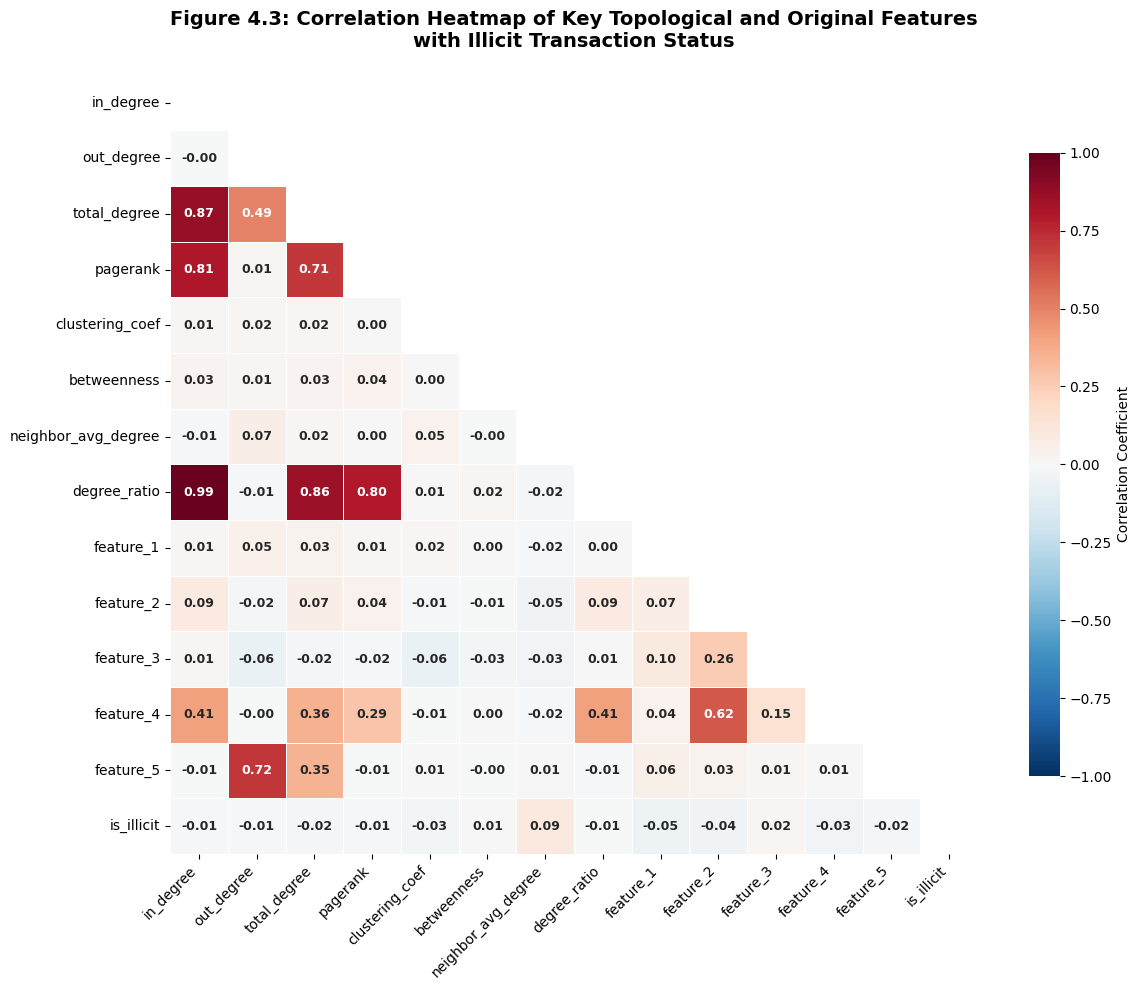


Correlations with Illicit Status:
  neighbor_avg_degree: +0.0948 (weak positive)
  feature_1: -0.0529 (weak negative)
  feature_2: -0.0404 (weak negative)
  feature_4: -0.0332 (weak negative)
  clustering_coef: -0.0294 (weak negative)
  feature_3: +0.0195 (weak positive)
  total_degree: -0.0172 (weak negative)
  feature_5: -0.0162 (weak negative)
  out_degree: -0.0149 (weak negative)
  in_degree: -0.0112 (weak negative)
  pagerank: -0.0093 (weak negative)
  degree_ratio: -0.0068 (weak negative)
  betweenness: +0.0059 (weak positive)


In [ ]:
# This visualization shows the correlation between engineered topological features and the target variable

key_features = [
    'in_degree', 'out_degree', 'total_degree', 'pagerank', 
    'clustering_coef', 'betweenness', 'neighbor_avg_degree', 'degree_ratio',
    'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'
]

corr_data = data[data['class_label'].isin(['1', '2'])].copy()
corr_data['is_illicit'] = corr_data['class_label'].apply(lambda x: 1 if x == '1' else 0)

available_features = [f for f in key_features if f in corr_data.columns]
correlation_df = corr_data[available_features + ['is_illicit']].copy()
corr_matrix = correlation_df.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmax=1, vmin=-1, center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            annot_kws={'size': 9, 'weight': 'bold'})

plt.title('Figure 4.3: Correlation Heatmap of Key Topological and Original Features\nwith Illicit Transaction Status', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('figure_4_3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

target_correlations = corr_matrix['is_illicit'].drop('is_illicit').sort_values(key=abs, ascending=False)
print("\nCorrelations with Illicit Status:")
for feature, corr_val in target_correlations.items():
    direction = "positive" if corr_val > 0 else "negative"
    strength = "strong" if abs(corr_val) > 0.3 else ("moderate" if abs(corr_val) > 0.1 else "weak")
    print(f"  {feature}: {corr_val:+.4f} ({strength} {direction})")

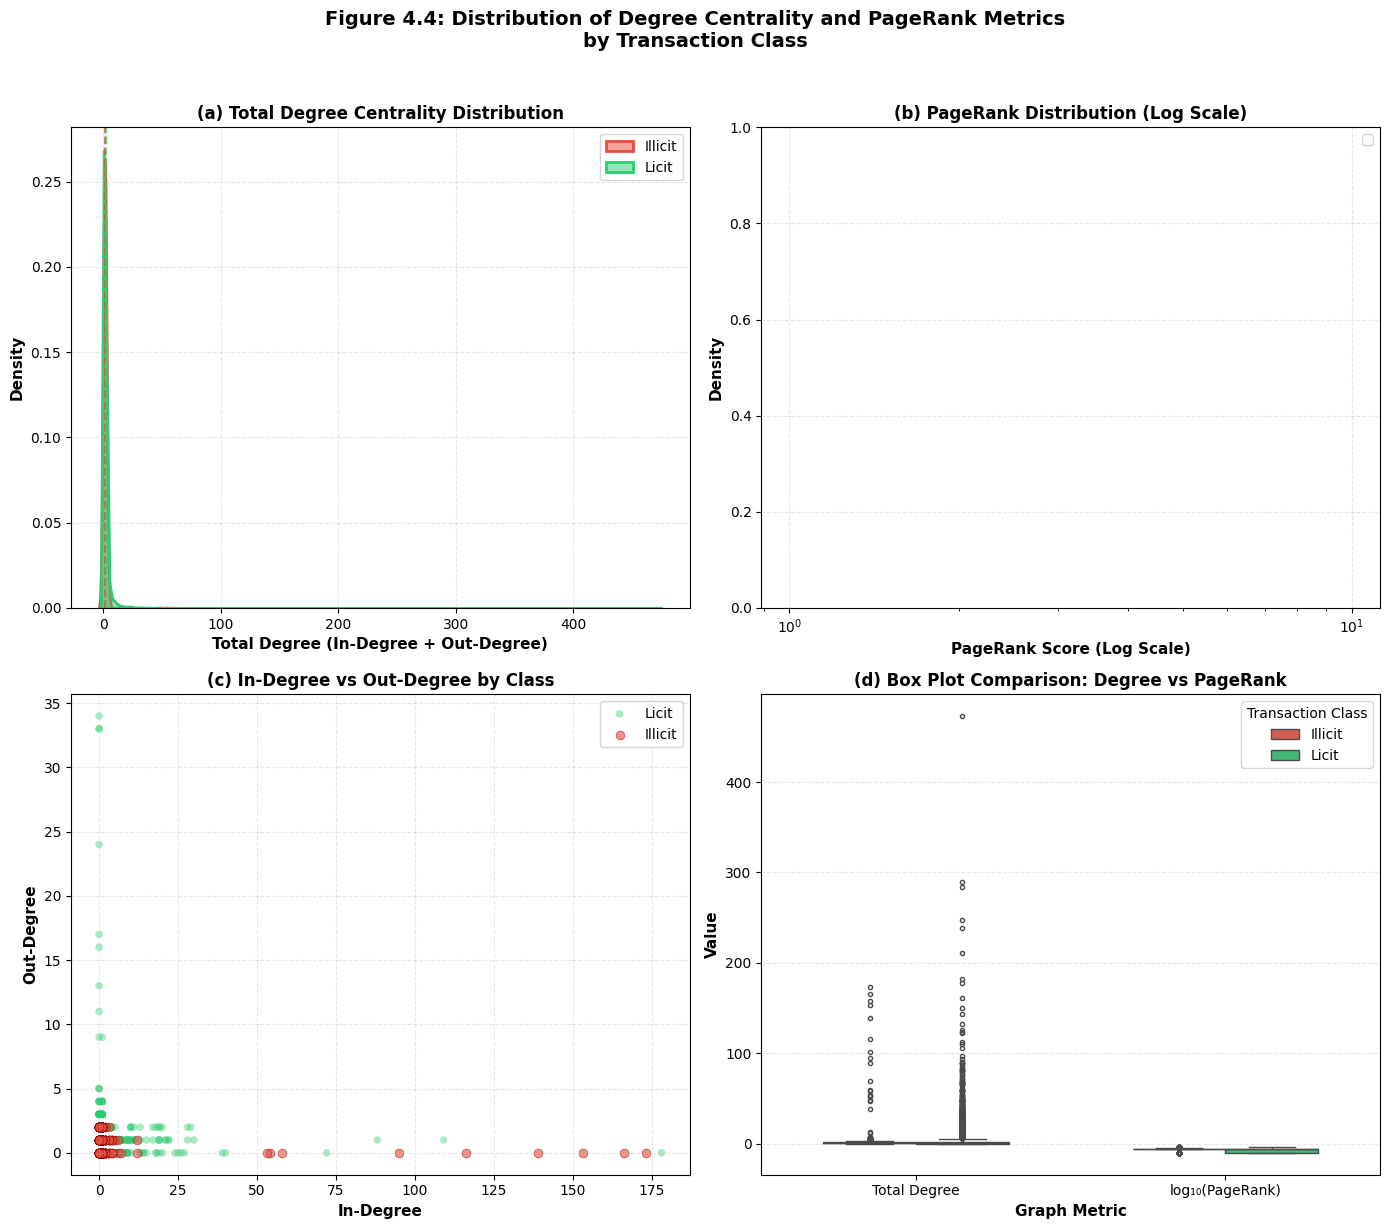

Total Degree - Illicit: Mean=1.611, Median=1.000
Total Degree - Licit: Mean=1.956, Median=1.000
PageRank - Illicit: Mean=0.00000472, Licit: Mean=0.00000523


In [ ]:
# Filter to training-period labeled data with actual graph connectivity
labeled_data = data[(data['class_label'].isin(['1', '2'])) & (data['time_step'] <= 35)].copy()

# Filter to nodes that actually have graph features (non-zero degree)
labeled_data = labeled_data[labeled_data['total_degree'] > 0]

illicit_data = labeled_data[labeled_data['class_label'] == '1']
licit_data = labeled_data[labeled_data['class_label'] == '2']

print(f"Nodes with graph features: {len(labeled_data):,}")
print(f"  Illicit: {len(illicit_data):,}")
print(f"  Licit: {len(licit_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Figure 4.4: Distribution of Degree Centrality and PageRank Metrics\nby Transaction Class (Training Period Nodes)', 
             fontsize=14, fontweight='bold', y=1.02)
illicit_color, licit_color = '#e74c3c', '#2ecc71'

# (a) Total Degree Distribution - use log transform for better visualization
ax1 = axes[0, 0]
sns.kdeplot(data=np.log1p(illicit_data['total_degree']), ax=ax1, label='Illicit', fill=True, color=illicit_color, alpha=0.5, linewidth=2)
sns.kdeplot(data=np.log1p(licit_data['total_degree']), ax=ax1, label='Licit', fill=True, color=licit_color, alpha=0.5, linewidth=2)
ax1.set_xlabel('log(1 + Total Degree)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.set_title('(a) Total Degree Centrality Distribution', fontsize=12, fontweight='bold')
ax1.axvline(np.log1p(illicit_data['total_degree'].mean()), color=illicit_color, linestyle='--', linewidth=1.5, alpha=0.8, label=f'Illicit Mean')
ax1.axvline(np.log1p(licit_data['total_degree'].mean()), color=licit_color, linestyle='--', linewidth=1.5, alpha=0.8, label=f'Licit Mean')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# (b) PageRank Distribution - filter out zero values for log scale
ax2 = axes[0, 1]
illicit_pagerank = illicit_data[illicit_data['pagerank'] > 0]['pagerank']
licit_pagerank = licit_data[licit_data['pagerank'] > 0]['pagerank']

if len(illicit_pagerank) > 0 and len(licit_pagerank) > 0:
    sns.kdeplot(data=illicit_pagerank, ax=ax2, label='Illicit', fill=True, color=illicit_color, alpha=0.5, linewidth=2, log_scale=True)
    sns.kdeplot(data=licit_pagerank, ax=ax2, label='Licit', fill=True, color=licit_color, alpha=0.5, linewidth=2, log_scale=True)
else:
    # Fallback: use log transform instead of log scale
    sns.kdeplot(data=np.log10(illicit_data['pagerank'] + 1e-10), ax=ax2, label='Illicit', fill=True, color=illicit_color, alpha=0.5, linewidth=2)
    sns.kdeplot(data=np.log10(licit_data['pagerank'] + 1e-10), ax=ax2, label='Licit', fill=True, color=licit_color, alpha=0.5, linewidth=2)

ax2.set_xlabel('PageRank Score (Log Scale)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Density', fontsize=11, fontweight='bold')
ax2.set_title('(b) PageRank Distribution (Log Scale)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

# (c) In-Degree vs Out-Degree Scatter
ax3 = axes[1, 0]
sample_size = min(2000, len(licit_data), len(illicit_data))
licit_sample = licit_data.sample(n=min(sample_size, len(licit_data)), random_state=42)
illicit_sample = illicit_data.sample(n=min(sample_size, len(illicit_data)), random_state=42)

ax3.scatter(licit_sample['in_degree'], licit_sample['out_degree'], c=licit_color, alpha=0.4, s=30, label='Licit', edgecolors='none')
ax3.scatter(illicit_sample['in_degree'], illicit_sample['out_degree'], c=illicit_color, alpha=0.6, s=40, label='Illicit', edgecolors='darkred', linewidths=0.5)
ax3.set_xlabel('In-Degree', fontsize=11, fontweight='bold')
ax3.set_ylabel('Out-Degree', fontsize=11, fontweight='bold')
ax3.set_title('(c) In-Degree vs Out-Degree by Class', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--')

# (d) Box Plot Comparison
ax4 = axes[1, 1]
box_data = pd.DataFrame({
    'Total Degree': pd.concat([illicit_data['total_degree'], licit_data['total_degree']]),
    'log₁₀(PageRank)': pd.concat([np.log10(illicit_data['pagerank'] + 1e-10), np.log10(licit_data['pagerank'] + 1e-10)]),
    'Class': ['Illicit'] * len(illicit_data) + ['Licit'] * len(licit_data)
})

box_melted = box_data.melt(id_vars=['Class'], var_name='Metric', value_name='Value')
sns.boxplot(data=box_melted, x='Metric', y='Value', hue='Class', ax=ax4, 
            palette={'Illicit': illicit_color, 'Licit': licit_color}, width=0.6, fliersize=3)
ax4.set_xlabel('Graph Metric', fontsize=11, fontweight='bold')
ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
ax4.set_title('(d) Box Plot Comparison: Degree vs PageRank', fontsize=12, fontweight='bold')
ax4.legend(title='Transaction Class', loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('figure_4_4_degree_pagerank_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nStatistics (Training Period Nodes with Graph Connectivity):")
print(f"Total Degree - Illicit: Mean={illicit_data['total_degree'].mean():.3f}, Median={illicit_data['total_degree'].median():.3f}")
print(f"Total Degree - Licit: Mean={licit_data['total_degree'].mean():.3f}, Median={licit_data['total_degree'].median():.3f}")
print(f"PageRank - Illicit: Mean={illicit_data['pagerank'].mean():.8f}, Median={illicit_data['pagerank'].median():.8f}")
print(f"PageRank - Licit: Mean={licit_data['pagerank'].mean():.8f}, Median={licit_data['pagerank'].median():.8f}")

In [ ]:
# Analyze graph features by class
for class_label in ['1', '2']:
    if class_label in data['class_label'].values:
        class_data = data[data['class_label'] == class_label]
        class_name = 'Illicit' if class_label == '1' else 'Licit'

        print(f"\n{class_name} Transactions (Class {class_label}, n={len(class_data):,}):")
        print(f"  Mean in-degree:    {class_data['in_degree'].mean():.3f}")
        print(f"  Mean out-degree:   {class_data['out_degree'].mean():.3f}")
        print(f"  Mean total degree: {class_data['total_degree'].mean():.3f}")
        print(f"  Mean PageRank:     {class_data['pagerank'].mean():.8f}")
        print(f"  Max PageRank:      {class_data['pagerank'].max():.8f}")
        
print(f"New features added: in_degree, out_degree, total_degree, pagerank")




Illicit Transactions (Class 1, n=4,545):
  Mean in-degree:    1.006
  Mean out-degree:   0.605
  Mean total degree: 1.611
  Mean PageRank:     0.00000472
  Max PageRank:      0.00043560

Licit Transactions (Class 2, n=42,019):
  Mean in-degree:    1.202
  Mean out-degree:   0.754
  Mean total degree: 1.956
  Mean PageRank:     0.00000523
  Max PageRank:      0.00068251
New features added: in_degree, out_degree, total_degree, pagerank


**Model Building (Machine Learning)**

In [ ]:
# Prepare features and datasets for model training

# Define feature groups
original_features = [col for col in data.columns if col.startswith('feature_')]

baseline_features = original_features.copy()

lstm_features = original_features + temporal_features

gnn_features = ['in_degree', 'out_degree', 'total_degree', 'pagerank', 
                'clustering_coef', 'betweenness', 'neighbor_avg_degree', 'degree_ratio']

# Prepare training and test datasets using temporal split
labeled_data = data[data['class_label'].isin(['1', '2'])].copy()

early_periods = labeled_data[labeled_data['time_step'] <= 35]
late_periods = labeled_data[labeled_data['time_step'] > 35]

X_train_modeling = early_periods[baseline_features]
y_train_modeling = early_periods['class_label']
X_test_modeling = late_periods[baseline_features]
y_test_modeling = late_periods['class_label']

print(f"Feature groups defined:")
print(f"  - Original features: {len(original_features)}")
print(f"  - Baseline features: {len(baseline_features)}")
print(f"  - LSTM features: {len(lstm_features)}")
print(f"  - GNN features: {len(gnn_features)}")
print(f"\nTraining samples: {len(X_train_modeling):,}")
print(f"Test samples: {len(X_test_modeling):,}")
print(f"Training class distribution: {y_train_modeling.value_counts().to_dict()}")
print(f"Test class distribution: {y_test_modeling.value_counts().to_dict()}")

Feature groups defined:
  - Original features: 165
  - Baseline features: 165
  - LSTM features: 179
  - GNN features: 8

Training samples: 31,235
Test samples: 15,329
Training class distribution: {'2': 27591, '1': 3644}
Test class distribution: {'2': 14428, '1': 901}


In [ ]:
# BASELINE MODEL 1: LOGISTIC REGRESSION

with tqdm(total=4, desc="Logistic Regression", unit="step", colour="blue") as pbar:
    
    print(f"  Using {len(baseline_features)} baseline features for Logistic Regression")

    # Extract baseline features from training data
    X_train_baseline = X_train_modeling[baseline_features]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_baseline)
    X_test_scaled = scaler.transform(X_test_modeling)
    pbar.update(1)
    pbar.set_postfix({"status": "Features scaled"})

    lr_model = LogisticRegression(
        class_weight='balanced', 
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    lr_model.fit(X_train_scaled, y_train_modeling)
    pbar.update(1)
    pbar.set_postfix({"status": "Model trained"})

    y_pred_lr = lr_model.predict(X_test_scaled)
    y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
    pbar.update(1)
    pbar.set_postfix({"status": "Predictions generated"})
    
    labeled_test_mask = y_test_modeling.isin(['1', '2'])
    y_test_labeled = y_test_modeling[labeled_test_mask]
    y_pred_labeled = y_pred_lr[labeled_test_mask]
    y_proba_labeled = y_proba_lr[labeled_test_mask]
    
    # Convert to numeric for metrics
    y_test_labeled_numeric = y_test_labeled.map({'1': 1, '2': 0})
    y_pred_lr_numeric = (y_pred_labeled == '1').astype(int)
    
    pbar.update(1)
    pbar.set_postfix({"status": "Model evaluated"})


print(f"Evaluating on {len(y_test_labeled):,} labeled test samples")
print(f"  Illicit: {(y_test_labeled == '1').sum():,}")
print(f"  Licit: {(y_test_labeled == '2').sum():,}")

print(classification_report(
    y_test_labeled,
    y_pred_labeled,
    labels=['2', '1'],
    target_names=['Licit (2)', 'Illicit (1)']
))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_labeled, y_pred_labeled, labels=['2', '1'])
print(cm)
print(f"  True Negatives:  {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,}")
print(f"  True Positives:  {cm[1,1]:,}")

# Advanced metrics
auc_roc = roc_auc_score(y_test_labeled, y_proba_labeled)
auc_pr = average_precision_score(y_test_labeled, y_proba_labeled, pos_label='1')
mcc = matthews_corrcoef(y_test_labeled, y_pred_labeled)

print(f"\nAUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR:  {auc_pr:.4f}")
print(f"MCC:     {mcc:.4f}")

print("\n Logistic Regression training completed")

Logistic Regression:   0%|          | 0/4 [00:00<?, ?step/s]

  Using 165 baseline features for Logistic Regression


Logistic Regression: 100%|██████████| 4/4 [00:09<00:00,  2.48s/step, status=Model evaluated]      


Evaluating on 15,329 labeled test samples
  Illicit: 901
  Licit: 14,428
              precision    recall  f1-score   support

   Licit (2)       0.98      0.77      0.86     14428
 Illicit (1)       0.18      0.79      0.29       901

    accuracy                           0.77     15329
   macro avg       0.58      0.78      0.58     15329
weighted avg       0.94      0.77      0.83     15329


Confusion Matrix:
[[11110  3318]
 [  185   716]]
  True Negatives:  11,110
  False Positives: 3,318
  False Negatives: 185
  True Positives:  716

AUC-ROC: 0.8781
AUC-PR:  0.0319
MCC:     0.3016

 Logistic Regression training completed


In [ ]:
# BASELINE MODEL 2: RANDOM FOREST

with tqdm(total=4, desc="Random Forest", unit="step", colour="green") as pbar:
    from sklearn.ensemble import RandomForestClassifier

    # Step 1: Extract features
    print("  Step 1: Extracting features...")
    print(f"  Using {len(baseline_features)} baseline features for Random Forest")
    X_train_baseline = X_train_modeling[baseline_features]
    pbar.update(1)
    pbar.set_postfix({"status": "Features extracted"})

    rf_model = RandomForestClassifier(
        n_estimators=200,          
        max_depth=20,             
        min_samples_split=10,      
        min_samples_leaf=5,        
        class_weight='balanced',   
        random_state=42,
        n_jobs=-1,               
        verbose=0
    )
    rf_model.fit(X_train_baseline, y_train_modeling)
    pbar.update(1)
    pbar.set_postfix({"status": "Model trained"})

    y_pred_rf = rf_model.predict(X_test_modeling)
    y_proba_rf = rf_model.predict_proba(X_test_modeling)[:, 1]

    # Filter to labeled test samples
    y_pred_rf_labeled = y_pred_rf[labeled_test_mask]
    y_proba_rf_labeled = y_proba_rf[labeled_test_mask]
    pbar.update(1)
    pbar.set_postfix({"status": "Predictions generated"})


    auc_roc_rf = roc_auc_score(y_test_labeled, y_proba_rf_labeled)
    pbar.update(1)
    pbar.set_postfix({"AUC-ROC": f"{auc_roc_rf:.4f}"})
    
print("\nClassification Report:")
print(classification_report(
    y_test_labeled,
    y_pred_rf_labeled,
    labels=['2', '1'],
    target_names=['Licit (2)', 'Illicit (1)']
))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test_labeled, y_pred_rf_labeled, labels=['2', '1'])
print(cm_rf)
print(f"  True Negatives:  {cm_rf[0,0]:,}")
print(f"  False Positives: {cm_rf[0,1]:,}")
print(f"  False Negatives: {cm_rf[1,0]:,}")
print(f"  True Positives:  {cm_rf[1,1]:,}")

# Advanced metrics
auc_pr_rf = average_precision_score(y_test_labeled, y_proba_rf_labeled, pos_label='1')
mcc_rf = matthews_corrcoef(y_test_labeled, y_pred_rf_labeled)

print(f"\nAUC-ROC: {auc_roc_rf:.4f}")
print(f"AUC-PR:  {auc_pr_rf:.4f}")
print(f"MCC:     {mcc_rf:.4f}")

# Feature importance analysis

feature_importance = pd.DataFrame({
    'feature': original_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

Random Forest:   0%|          | 0/4 [00:00<?, ?step/s]

Random Forest:  25%|██▌       | 1/4 [00:00<00:00, 20.11step/s, status=Features extracted]

  Step 1: Extracting features...
  Using 165 baseline features for Random Forest


Random Forest: 100%|██████████| 4/4 [00:10<00:00,  2.70s/step, AUC-ROC=0.9218]              



Classification Report:
              precision    recall  f1-score   support

   Licit (2)       0.98      1.00      0.99     14428
 Illicit (1)       0.94      0.68      0.79       901

    accuracy                           0.98     15329
   macro avg       0.96      0.84      0.89     15329
weighted avg       0.98      0.98      0.98     15329


Confusion Matrix:
[[14391    37]
 [  292   609]]
  True Negatives:  14,391
  False Positives: 37
  False Negatives: 292
  True Positives:  609

AUC-ROC: 0.9218
AUC-PR:  0.0308
MCC:     0.7883
   feature  importance
feature_55    0.050641
feature_47    0.049299
feature_41    0.043234
feature_53    0.040099
feature_49    0.039678
feature_43    0.038416
feature_90    0.029532
feature_18    0.029272
feature_29    0.027383
feature_14    0.022468


In [ ]:
# BASELINE MODEL 3: XGBoost

with tqdm(total=4, desc="XGBoost", unit="step", colour="yellow") as pbar:
    scale_pos_weight = (y_train_modeling == '2').sum() / (y_train_modeling == '1').sum()
    print(f"  Class imbalance in training: {scale_pos_weight:.1f}:1")
    print(f"  Using scale_pos_weight = {scale_pos_weight:.2f}")
    
    # Convert string labels to numeric for XGBoost
    label_map = {'2': 0, '1': 1}
    y_train_numeric = y_train_modeling.map(label_map)
    y_test_numeric = y_test_modeling.map(label_map)
    y_test_labeled_numeric = y_test_labeled.map(label_map)
    
    print(f"  Using {len(baseline_features)} baseline features for XGBoost")
    X_train_baseline = X_train_modeling[baseline_features]
    pbar.update(1)
    pbar.set_postfix({"status": "Data prepared"})
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,  # Handle imbalance
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(X_train_baseline, y_train_numeric)
    pbar.update(1)
    pbar.set_postfix({"status": "Model trained"})

    y_pred_xgb = xgb_model.predict(X_test_modeling)
    y_proba_xgb = xgb_model.predict_proba(X_test_modeling)[:, 1]

    # Filter to labeled test samples
    y_pred_xgb_labeled = y_pred_xgb[labeled_test_mask]
    y_proba_xgb_labeled = y_proba_xgb[labeled_test_mask]
    pbar.update(1)
    pbar.set_postfix({"status": "Predictions generated"})

    auc_roc_xgb = roc_auc_score(y_test_labeled_numeric, y_proba_xgb_labeled)
    pbar.update(1)
    pbar.set_postfix({"AUC-ROC": f"{auc_roc_xgb:.4f}"})

print("\nClassification Report:")
print(classification_report(y_test_labeled_numeric, y_pred_xgb_labeled, target_names=['Licit (0)', 'Illicit (1)']))

print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test_labeled_numeric, y_pred_xgb_labeled)
print(cm_xgb)
print(f"  True Negatives:  {cm_xgb[0,0]:,}")
print(f"  False Positives: {cm_xgb[0,1]:,}")
print(f"  False Negatives: {cm_xgb[1,0]:,}")
print(f"  True Positives:  {cm_xgb[1,1]:,}")

# Advanced metrics
auc_pr_xgb = average_precision_score(y_test_labeled_numeric, y_proba_xgb_labeled)
mcc_xgb = matthews_corrcoef(y_test_labeled_numeric, y_pred_xgb_labeled)

print(f"\nAUC-ROC: {auc_roc_xgb:.4f}")
print(f"AUC-PR:  {auc_pr_xgb:.4f}")
print(f"MCC:     {mcc_xgb:.4f}")

# Feature importance
xgb_feature_importance = pd.DataFrame({
    'feature': original_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(xgb_feature_importance.head(10).to_string(index=False))

XGBoost:   0%|          | 0/4 [00:00<?, ?step/s]

  Class imbalance in training: 7.6:1
  Using scale_pos_weight = 7.57
  Using 165 baseline features for XGBoost


XGBoost: 100%|██████████| 4/4 [00:06<00:00,  1.66s/step, AUC-ROC=0.9397]              


Classification Report:
              precision    recall  f1-score   support

   Licit (0)       0.98      1.00      0.99     14428
 Illicit (1)       0.95      0.67      0.79       901

    accuracy                           0.98     15329
   macro avg       0.96      0.84      0.89     15329
weighted avg       0.98      0.98      0.98     15329


Confusion Matrix:
[[14393    35]
 [  293   608]]
  True Negatives:  14,393
  False Positives: 35
  False Negatives: 293
  True Positives:  608

AUC-ROC: 0.9397
AUC-PR:  0.7779
MCC:     0.7889
    feature  importance
 feature_53    0.097248
 feature_46    0.062039
 feature_41    0.059133
  feature_5    0.053069
 feature_90    0.050211
feature_163    0.044180
feature_103    0.044117
 feature_40    0.042795
 feature_59    0.028960
 feature_55    0.028566


In [ ]:
# THRESHOLD OPTIMIZATION

thresholds_to_test = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds_to_test:
    # Apply threshold
    y_pred_thresh = (y_proba_xgb_labeled >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_test_labeled_numeric, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test_labeled_numeric, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test_labeled_numeric, y_pred_thresh, zero_division=0)

    # Calculate specificity (True Negative Rate)
    cm_temp = confusion_matrix(y_test_labeled_numeric, y_pred_thresh)
    if cm_temp.shape == (2, 2):
        specificity = cm_temp[0,0] / (cm_temp[0,0] + cm_temp[0,1]) if (cm_temp[0,0] + cm_temp[0,1]) > 0 else 0
    else:
        specificity = 0

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)

# Find optimal thresholds for different objectives
best_f1_idx = threshold_df['f1_score'].idxmax()
best_precision_idx = threshold_df['precision'].idxmax()
best_recall_idx = threshold_df['recall'].idxmax()

print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Specificity':<12}")

for _, row in threshold_df.iterrows():
    marker = ""
    if row.name == best_f1_idx:
        marker = " ← BEST F1"
    elif row.name == best_precision_idx:
        marker = " ← BEST PRECISION"
    elif row.name == best_recall_idx:
        marker = " ← BEST RECALL"

    print(f"{row['threshold']:<12.2f} {row['precision']:<12.3f} {row['recall']:<12.3f} "
          f"{row['f1_score']:<12.3f} {row['specificity']:<12.3f}{marker}")
# Find closest threshold to 0.6 for high precision
high_precision_idx = (threshold_df['threshold'] - 0.6).abs().idxmin()
high_precision_row = threshold_df.loc[high_precision_idx]
print(f"\n2. HIGH PRECISION (Minimize False Alarms):")
print(f"   Threshold: {high_precision_row['threshold']:.2f}")
print(f"   Precision: {high_precision_row['precision']:.3f}")
print(f"   Recall: {high_precision_row['recall']:.3f}")
print(f"   F1-Score: {high_precision_row['f1_score']:.3f}")
print(f"   → Use when false alarms are very costly")

# Find closest threshold to 0.3 for high recall
high_recall_idx = (threshold_df['threshold'] - 0.3).abs().idxmin()
high_recall_row = threshold_df.loc[high_recall_idx]
print(f"\n3. HIGH RECALL (Catch More Fraud):")
print(f"   Threshold: {high_recall_row['threshold']:.2f}")
print(f"   Precision: {high_recall_row['precision']:.3f}")
print(f"   Recall: {high_recall_row['recall']:.3f}")
print(f"   F1-Score: {high_recall_row['f1_score']:.3f}")
print(f"   → Use when missing fraud is very costly")

print("\nThreshold optimization completed")



Threshold    Precision    Recall       F1-Score     Specificity 
0.10         0.665        0.705        0.684        0.978        ← BEST RECALL
0.15         0.742        0.698        0.719        0.985       
0.20         0.798        0.691        0.741        0.989       
0.25         0.840        0.688        0.757        0.992       
0.30         0.871        0.683        0.765        0.994       
0.35         0.899        0.680        0.774        0.995       
0.40         0.915        0.679        0.780        0.996       
0.45         0.934        0.676        0.784        0.997       
0.50         0.946        0.675        0.788        0.998       
0.55         0.953        0.671        0.788        0.998       
0.60         0.960        0.671        0.790        0.998       
0.65         0.971        0.670        0.793        0.999        ← BEST F1
0.70         0.976        0.666        0.792        0.999       
0.75         0.985        0.661        0.792        0.999       


In [ ]:
# ENSEMBLE MODEL - Combining Logistic Regression, Random Forest, and XGBoost

with tqdm(total=5, desc="Ensemble Model", unit="step", colour="magenta") as pbar:

    # For LR and RF with string labels, find which column corresponds to '1' (illicit)
    lr_illicit_idx = list(lr_model.classes_).index('1')
    rf_illicit_idx = list(rf_model.classes_).index('1')

    # Get probabilities for illicit class ('1') from each model
    y_proba_lr_all = lr_model.predict_proba(X_test_scaled)[:, lr_illicit_idx]
    y_proba_rf_all = rf_model.predict_proba(X_test_modeling)[:, rf_illicit_idx]
    y_proba_xgb_all = y_proba_xgb  # Already correct (column 1 = illicit)

    # Filter to labeled test samples
    y_proba_lr_labeled_fixed = y_proba_lr_all[labeled_test_mask]
    y_proba_rf_labeled_fixed = y_proba_rf_all[labeled_test_mask]
    y_proba_xgb_labeled_fixed = y_proba_xgb_labeled  # Already filtered and correct

    print(f"\n  Probability statistics for illicit class:")
    print(f"    LR mean: {y_proba_lr_labeled_fixed.mean():.4f}")
    print(f"    RF mean: {y_proba_rf_labeled_fixed.mean():.4f}")
    print(f"    XGB mean: {y_proba_xgb_labeled_fixed.mean():.4f}")
    pbar.update(1)
    pbar.set_postfix({"status": "Probabilities validated"})

    # Calculate ensemble weights
    total_auc = auc_roc + auc_roc_rf + auc_roc_xgb
    weight_lr = auc_roc / total_auc
    weight_rf = auc_roc_rf / total_auc
    weight_xgb = auc_roc_xgb / total_auc

    print(f"\n  Ensemble weights (based on AUC-ROC):")
    print(f"    Logistic Regression: {weight_lr:.3f}")
    print(f"    Random Forest:       {weight_rf:.3f}")
    print(f"    XGBoost:            {weight_xgb:.3f}")
    pbar.update(1)
    pbar.set_postfix({"status": "Weights calculated"})

    # Combine predictions with weighted averaging
    print("\n  Step 3: Combining predictions with weighted averaging...")
    y_proba_ensemble = (
        weight_lr * y_proba_lr_labeled_fixed +
        weight_rf * y_proba_rf_labeled_fixed +
        weight_xgb * y_proba_xgb_labeled_fixed
    )

    print(f"\n  Ensemble probability statistics:")
    print(f"    Mean: {y_proba_ensemble.mean():.4f}")
    print(f"    Min: {y_proba_ensemble.min():.4f}")
    print(f"    Max: {y_proba_ensemble.max():.4f}")

    # Apply default threshold (0.5)
    y_pred_ensemble = (y_proba_ensemble >= 0.5).astype(int)

    # Convert to match original label format for evaluation
    y_pred_ensemble_str = pd.Series(y_pred_ensemble).map({0: '2', 1: '1'})
    pbar.update(1)
    pbar.set_postfix({"status": "Predictions combined"})

    # Evaluate ensemble model
    auc_roc_ensemble = roc_auc_score(y_test_labeled_numeric, y_proba_ensemble)
    auc_pr_ensemble = average_precision_score(y_test_labeled_numeric, y_proba_ensemble)
    mcc_ensemble = matthews_corrcoef(y_test_labeled, y_pred_ensemble_str)
    pbar.update(1)
    pbar.set_postfix({"AUC-ROC": f"{auc_roc_ensemble:.4f}"})

    # Generate confusion matrix
    cm_ensemble = confusion_matrix(y_test_labeled, y_pred_ensemble_str, labels=['2', '1'])
    pbar.update(1)
    pbar.set_postfix({"status": "Evaluation complete"})

print("\nClassification Report:")
print(classification_report(
    y_test_labeled,
    y_pred_ensemble_str,
    labels=['2', '1'],
    target_names=['Licit (2)', 'Illicit (1)']
))

print("\nConfusion Matrix:")
print(cm_ensemble)
print(f"  True Negatives:  {cm_ensemble[0,0]:,}")
print(f"  False Positives: {cm_ensemble[0,1]:,}")
print(f"  False Negatives: {cm_ensemble[1,0]:,}")
print(f"  True Positives:  {cm_ensemble[1,1]:,}")

print(f"\nAUC-ROC: {auc_roc_ensemble:.4f}")
print(f"AUC-PR:  {auc_pr_ensemble:.4f}")
print(f"MCC:     {mcc_ensemble:.4f}")

print("\nEnsemble model training completed")

Ensemble Model: 100%|██████████| 5/5 [00:00<00:00, 11.38step/s, status=Evaluation complete]    


  Probability statistics for illicit class:
    LR mean: 0.2541
    RF mean: 0.0908
    XGB mean: 0.0479

  Ensemble weights (based on AUC-ROC):
    Logistic Regression: 0.321
    Random Forest:       0.336
    XGBoost:            0.343

  Step 3: Combining predictions with weighted averaging...

  Ensemble probability statistics:
    Mean: 0.1284
    Min: 0.0000
    Max: 0.9990

Classification Report:


              precision    recall  f1-score   support

   Licit (2)       0.98      0.99      0.99     14428
 Illicit (1)       0.84      0.68      0.75       901

    accuracy                           0.97     15329
   macro avg       0.91      0.84      0.87     15329
weighted avg       0.97      0.97      0.97     15329


Confusion Matrix:
[[14313   115]
 [  286   615]]
  True Negatives:  14,313
  False Positives: 115
  False Negatives: 286
  True Positives:  615

AUC-ROC: 0.9324
AUC-PR:  0.7576
MCC:     0.7451

Ensemble model training completed


In [ ]:
# EXTENDED COMPARISON WITH DEEP LEARNING MODELS

ml_models_results = {
    'Logistic Regression': {'y_pred': y_pred_lr_numeric, 'y_proba': y_proba_lr_labeled_fixed},
    'Random Forest': {'y_pred': (y_pred_rf_labeled == '1').astype(int), 'y_proba': y_proba_rf_labeled_fixed},
    'XGBoost': {'y_pred': y_pred_xgb_labeled, 'y_proba': y_proba_xgb_labeled},
    'Ensemble (ML)': {'y_pred': y_pred_ensemble, 'y_proba': y_proba_ensemble}
}

Visualization: 100%|██████████| 4/4 [00:04<00:00,  1.18s/plot, status=All plots complete]

  Visualization saved as 'model_comparison_visualization.png'


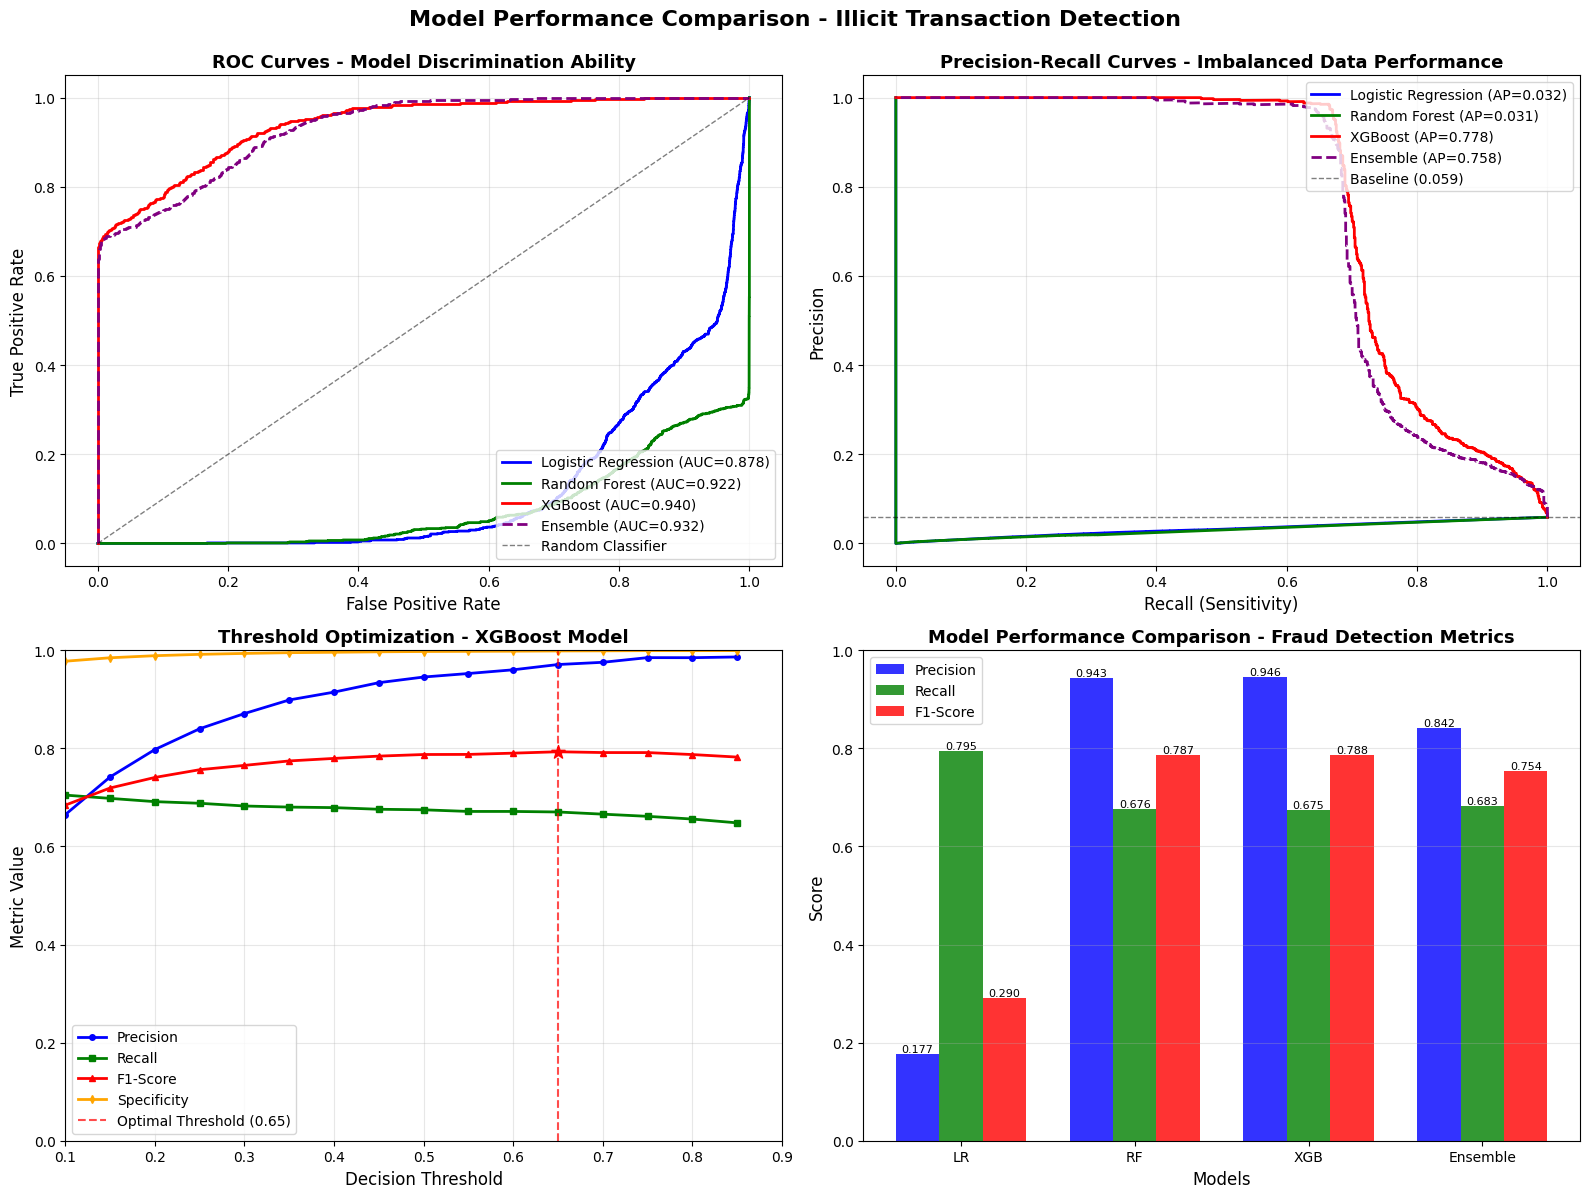

In [ ]:
# VISUALIZATION (ROC & PR Curves for Model Comparison)
with tqdm(total=4, desc="Visualization", unit="plot", colour="cyan") as pbar:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Performance Comparison - Illicit Transaction Detection', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    ax1 = axes[0, 0]

    # Calculate ROC curves for each model
    fpr_lr, tpr_lr, _ = roc_curve(y_test_labeled_numeric, y_proba_labeled)
    fpr_rf, tpr_rf, _ = roc_curve(y_test_labeled_numeric, y_proba_rf_labeled)
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test_labeled_numeric, y_proba_xgb_labeled)
    fpr_ens, tpr_ens, _ = roc_curve(y_test_labeled_numeric, y_proba_ensemble)

    # Plot each model
    ax1.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_roc:.3f})', 
             linewidth=2, color='blue')
    ax1.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_roc_rf:.3f})', 
             linewidth=2, color='green')
    ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_roc_xgb:.3f})', 
             linewidth=2, color='red')
    ax1.plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC={auc_roc_ensemble:.3f})', 
             linewidth=2, color='purple', linestyle='--')

    # Add diagonal reference line (random classifier)
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curves - Model Discrimination Ability', fontsize=13, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    pbar.update(1)
    pbar.set_postfix({"status": "ROC curves"})

    # PLOT 2: Precision-Recall Curves

    ax2 = axes[0, 1]

    # Calculate PR curves for each model
    precision_lr, recall_lr, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_labeled)
    precision_rf, recall_rf, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_rf_labeled)
    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_xgb_labeled)
    precision_ens, recall_ens, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_ensemble)

    # Plot each model
    ax2.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP={auc_pr:.3f})', 
             linewidth=2, color='blue')
    ax2.plot(recall_rf, precision_rf, label=f'Random Forest (AP={auc_pr_rf:.3f})', 
             linewidth=2, color='green')
    ax2.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={auc_pr_xgb:.3f})', 
             linewidth=2, color='red')
    ax2.plot(recall_ens, precision_ens, label=f'Ensemble (AP={auc_pr_ensemble:.3f})', 
             linewidth=2, color='purple', linestyle='--')

    # Add baseline (proportion of positive class)
    baseline_precision = (y_test_labeled_numeric == 1).sum() / len(y_test_labeled_numeric)
    ax2.axhline(y=baseline_precision, color='k', linestyle='--', linewidth=1, 
                alpha=0.5, label=f'Baseline ({baseline_precision:.3f})')

    ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Precision-Recall Curves - Imbalanced Data Performance', 
                  fontsize=13, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    pbar.update(1)
    pbar.set_postfix({"status": "PR curves"})

    # PLOT 3: Threshold Optimization (Bottom Left)
    ax3 = axes[1, 0]

    # Plot metrics vs threshold
    ax3.plot(threshold_df['threshold'], threshold_df['precision'], 
             label='Precision', linewidth=2, color='blue', marker='o', markersize=4)
    ax3.plot(threshold_df['threshold'], threshold_df['recall'], 
             label='Recall', linewidth=2, color='green', marker='s', markersize=4)
    ax3.plot(threshold_df['threshold'], threshold_df['f1_score'], 
             label='F1-Score', linewidth=2, color='red', marker='^', markersize=4)
    ax3.plot(threshold_df['threshold'], threshold_df['specificity'], 
             label='Specificity', linewidth=2, color='orange', marker='d', markersize=4)

    # Mark optimal threshold
    optimal_thresh = threshold_df.loc[best_f1_idx, 'threshold']
    optimal_f1 = threshold_df.loc[best_f1_idx, 'f1_score']
    ax3.axvline(x=optimal_thresh, color='red', linestyle='--', linewidth=1.5, 
                alpha=0.7, label=f'Optimal Threshold ({optimal_thresh:.2f})')
    ax3.scatter([optimal_thresh], [optimal_f1], color='red', s=100, zorder=5, marker='*')

    ax3.set_xlabel('Decision Threshold', fontsize=12)
    ax3.set_ylabel('Metric Value', fontsize=12)
    ax3.set_title('Threshold Optimization - XGBoost Model', fontsize=13, fontweight='bold')
    ax3.legend(loc='best', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0.1, 0.9)
    ax3.set_ylim(0, 1)
    pbar.update(1)
    pbar.set_postfix({"status": "Threshold analysis"})

    # PLOT 4: Model Comparison Bar Chart
    ax4 = axes[1, 1]

    # Prepare data for bar chart
    models = ['LR', 'RF', 'XGB', 'Ensemble']
    
    # Helper to extract metrics from the stored results dictionary
    def get_metrics(name):
        y_p = ml_models_results[name]['y_pred']
        y_t = y_test_labeled_numeric 
        return precision_score(y_t, y_p), recall_score(y_t, y_p), f1_score(y_t, y_p)

    # Define the variables that were missing
    prec_lr, rec_lr, f1_lr = get_metrics('Logistic Regression')
    prec_rf, rec_rf, f1_rf = get_metrics('Random Forest')
    prec_xgb, rec_xgb, f1_xgb = get_metrics('XGBoost')
    prec_ens, rec_ens, f1_ens = get_metrics('Ensemble (ML)')
    metrics_data = {
        'Precision': [prec_lr, prec_rf, prec_xgb, prec_ens],
        'Recall': [rec_lr, rec_rf, rec_xgb, rec_ens],
        'F1-Score': [f1_lr, f1_rf, f1_xgb, f1_ens]
    }

    x = np.arange(len(models))
    width = 0.25

    # Create grouped bar chart
    bars1 = ax4.bar(x - width, metrics_data['Precision'], width, label='Precision', color='blue', alpha=0.8)
    bars2 = ax4.bar(x, metrics_data['Recall'], width, label='Recall', color='green', alpha=0.8)
    bars3 = ax4.bar(x + width, metrics_data['F1-Score'], width, label='F1-Score', color='red', alpha=0.8)

    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    ax4.set_xlabel('Models', fontsize=12)
    ax4.set_ylabel('Score', fontsize=12)
    ax4.set_title('Model Performance Comparison - Fraud Detection Metrics', 
                  fontsize=13, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(models)
    ax4.legend(loc='upper left', fontsize=10)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig('model_comparison_visualization.png', dpi=300, bbox_inches='tight')
    print("  Visualization saved as 'model_comparison_visualization.png'")
    pbar.update(1)
    pbar.set_postfix({"status": "All plots complete"})

**Deep Learning Model**

In [ ]:
# DEEP LEARNING CONFIGURATION

class DLConfig:
    
    # LSTM Model Architecture
    LSTM_HIDDEN_DIM = 64        
    LSTM_NUM_LAYERS = 1        
    LSTM_DROPOUT = 0.3            
    LSTM_BIDIRECTIONAL = False  
      
    # GNN Model Architecture  
    GNN_TYPE = 'GraphSAGE'        
    GNN_HIDDEN_DIM = 128          
    GNN_NUM_LAYERS = 2            
    GNN_DROPOUT = 0.3            
    GNN_AGGR = 'mean'             

    # Hybrid Model Architecture
    HYBRID_FUSION_DIM = 256       
    HYBRID_DROPOUT = 0.3          
    HYBRID_CONCAT_METHOD = 'concatenate'  
    USE_ATTENTION_FUSION = True 
    XGB_EMBEDDING_DIM = 16
    
    # Training Hyperparameters
    BATCH_SIZE = 256             
    NUM_EPOCHS = 30              
    LEARNING_RATE = 0.001        
    WEIGHT_DECAY = 1e-5          
    PATIENCE = 5                

    # Loss Function Configuration
    USE_CLASS_WEIGHTS = False     
    CLASS_WEIGHT_RATIO = 5.0     
    FOCAL_LOSS = False         
    
    # Device & Performance
    FORCE_CPU = False            
    NUM_WORKERS = 4              
    PIN_MEMORY = True          
    
    # Reproducibility
    RANDOM_SEED = 42             
    DETERMINISTIC = True       

    # Model Persistence
    SAVE_DIR = 'models/'       
    LSTM_MODEL_PATH = 'best_lstm_model.pth'
    GNN_MODEL_PATH = 'best_gnn_model.pth'
    HYBRID_MODEL_PATH = 'best_hybrid_model.pth'


    # Evaluation Metrics
    METRICS = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'auc_pr', 'mcc']
    THRESHOLD_OPTIMIZATION = True 
   
    # Explainability
    USE_SHAP = True       
    SHAP_SAMPLES = 100        


In [ ]:
# Check PyTorch installation and configure device
print(f"\nPyTorch Version: {torch.__version__}")



PyTorch Version: 2.8.0+cpu


In [ ]:
# Check for available acceleration devices
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"MPS (Apple Silicon GPU) Available: {torch.backends.mps.is_available()}")


CUDA Available: False
MPS (Apple Silicon GPU) Available: False


In [ ]:
# Default behavior: honor DLConfig.FORCE_CPU; otherwise prefer CUDA > MPS > CPU

if getattr(DLConfig, 'FORCE_CPU', False):
    device = torch.device('cpu')
    num_workers = getattr(DLConfig, 'NUM_WORKERS', 0)
    pin_memory = getattr(DLConfig, 'PIN_MEMORY', False)
    print("DLConfig.FORCE_CPU is True -> Forcing CPU execution (no GPU will be used)")
else:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        num_workers = 4
        pin_memory = True
        try:
            print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
        except Exception:
            pass
        print("Using NVIDIA CUDA GPU for training")
        # Enable TF32 (where supported) and cuDNN benchmark for speed
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        device = torch.device('mps')
        num_workers = 0
        pin_memory = False
        print("Using Apple MPS backend for training (note: LSTM performance may vary)")
    else:
        device = torch.device('cpu')
        num_workers = getattr(DLConfig, 'NUM_WORKERS', 0)
        pin_memory = getattr(DLConfig, 'PIN_MEMORY', False)
        print("No GPU backend available - using CPU for training")

print(f"\nDevice selected: {device}")



No GPU backend available - using CPU for training

Device selected: cpu


In [ ]:
# Set random seeds for reproducibility
seed = getattr(DLConfig, 'RANDOM_SEED', 42)
torch.manual_seed(seed)
np.random.seed(seed)

print("\nDeep learning environment configured successfully")



Deep learning environment configured successfully


In [ ]:
# PREPARE TEMPORAL SEQUENCE DATA FOR LSTM

train_temporal_df = data[(data['time_step'] <= 35) & (data['class_label'].isin(['1', '2']))].set_index('node_ID')
test_temporal_df = data[(data['time_step'] > 35) & (data['class_label'].isin(['1', '2']))].set_index('node_ID')

X_train_lstm_df = train_temporal_df[lstm_features]
y_train_lstm = (train_temporal_df['class_label'] == '1').astype(int)

print(f"LSTM training features: {len(lstm_features)} ({len(original_features)} original + {len(temporal_features)} temporal)")

# Convert pandas to numpy first, then to tensors on the selected device
X_train_np = X_train_lstm_df.values.astype(np.float32)
y_train_np = y_train_lstm.values.astype(np.int64)

with torch.no_grad():
    X_train_tensor = torch.from_numpy(X_train_np).to(device)
    y_train_tensor = torch.from_numpy(y_train_np).to(device)

print(f"Training tensor shape: {X_train_tensor.shape}")
print(f"Training labels shape: {y_train_tensor.shape}")
print(f"Training tensor device: {X_train_tensor.device}")

# Use numpy for class distribution calculation
unique, counts = np.unique(y_train_np, return_counts=True)
print(f"Training class distribution: {dict(zip(unique, counts))}")

# Prepare test sequences
# Use LSTM features for test data
print(f"LSTM test features: {len(lstm_features)}")
X_test_np = test_temporal_df[lstm_features].values.astype(np.float32)
y_test_np = (test_temporal_df['class_label'] == '1').astype(int).values.astype(np.int64)

with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test_np).to(device)
    y_test_tensor = torch.from_numpy(y_test_np).to(device)

print(f"Test tensor shape: {X_test_tensor.shape}")
print(f"Test labels shape: {y_test_tensor.shape}")
print(f"Test tensor device: {X_test_tensor.device}")

# Create DataLoaders for batch processing. Use DLConfig.BATCH_SIZE when available.
batch_size = getattr(DLConfig, 'BATCH_SIZE', 256) if device.type == 'cuda' else getattr(DLConfig, 'BATCH_SIZE', 128)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

print(f"\nDataLoaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Num workers: {num_workers}")
print(f"  Pin memory: {pin_memory}")

print(f"\nData prepared successfully on {device}")
print("\nTemporal sequence data preparation completed")

LSTM training features: 179 (165 original + 14 temporal)
Training tensor shape: torch.Size([31235, 179])
Training labels shape: torch.Size([31235])
Training tensor device: cpu
Training class distribution: {0: 27591, 1: 3644}
LSTM test features: 179
Test tensor shape: torch.Size([15329, 179])
Test labels shape: torch.Size([15329])
Test tensor device: cpu

DataLoaders created:
  Batch size: 256
  Training batches: 123
  Test batches: 60
  Num workers: 4
  Pin memory: True

Data prepared successfully on cpu

Temporal sequence data preparation completed


In [ ]:
# SIMPLIFIED LSTM MODEL ARCHITECTURE

print("BUILDING SIMPLIFIED LSTM TEMPORAL MODEL")


# Focal Loss implementation for deep models
class FocalLoss(nn.Module):
    """Focal Loss for addressing class imbalance - focuses on hard examples"""
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class SimpleLSTMFraudDetector(nn.Module):
    """
    Simplified LSTM for fraud detection - optimized for CPU training.
    Removed attention mechanism to avoid CPU deadlock issues.
    """
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.3):
        super(SimpleLSTMFraudDetector, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Single-direction LSTM (faster than bidirectional)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0,  # No dropout for single layer
            bidirectional=False  # Unidirectional for speed
        )

        # Simple classification layers
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 2)  # Binary classification

    def forward(self, x):
        # Reshape input to (batch, seq_len=1, features) for LSTM
        x = x.unsqueeze(1)

        # LSTM forward pass
        lstm_out, (hidden, cell) = self.lstm(x)

        # Use last hidden state (no attention)
        last_hidden = hidden[-1]  # Shape: (batch, hidden_dim)

        # Classification
        x = F.relu(self.fc1(last_hidden))
        x = self.dropout(x)
        output = self.fc2(x)

        return output


# Use lstm_features for LSTM input dimension

# Use only real labeled nodes (already prepared in train_temporal_df)
input_dim = len(lstm_features)
X_train_lstm = X_train_lstm_df
y_train_lstm = y_train_lstm
lstm_model = SimpleLSTMFraudDetector(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=1,
    dropout=0.3
).to(device)

print(f"\nModel Architecture (Optimized for CPU):")
print(f"  Input dimension: {input_dim}")
print(f"  Hidden dimension: 64 (reduced for speed)")
print(f"  Number of LSTM layers: 1 (unidirectional)")
print(f"  Dropout rate: 0.3")
print(f"\nTotal parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

print("\nSimplified LSTM model built successfully (no attention mechanism)")

BUILDING SIMPLIFIED LSTM TEMPORAL MODEL

Model Architecture (Optimized for CPU):
  Input dimension: 179
  Hidden dimension: 64 (reduced for speed)
  Number of LSTM layers: 1 (unidirectional)
  Dropout rate: 0.3

Total parameters: 64,866
Trainable parameters: 64,866

Simplified LSTM model built successfully (no attention mechanism)


In [ ]:
# TRAIN LSTM MODEL USING CONFIGURATION

print("TRAINING LSTM MODEL")

import time

# Use configuration parameters
cpu_device = torch.device('cpu')
lstm_model = lstm_model.to(cpu_device)

# Training setup from config

num_epochs = DLConfig.NUM_EPOCHS
learning_rate = DLConfig.LEARNING_RATE
batch_size = DLConfig.BATCH_SIZE
patience = DLConfig.PATIENCE

# Calculate class weights for real node training set
from sklearn.utils.class_weight import compute_class_weight
y_train_np = y_train_lstm.values if hasattr(y_train_lstm, 'values') else y_train_lstm
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train_np), y=y_train_np)
class_weights = torch.tensor(class_weights_array, dtype=torch.float32, device=cpu_device)
print(f"\nClass weights computed: {class_weights.cpu().numpy()}")
print(f"  Class 0 (licit) weight: {class_weights[0]:.4f}")
print(f"  Class 1 (illicit) weight: {class_weights[1]:.4f}")

# Use Focal Loss for deep models
criterion = FocalLoss(alpha=0.25, gamma=2.0, weight=class_weights)
print("Using Focal Loss with alpha=0.25, gamma=2.0")
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate, weight_decay=DLConfig.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"\nTraining configuration:")
print(f"  Device: {cpu_device}")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Learning rate: {learning_rate}")
print(f"  Training samples: {len(X_train_tensor):,}")
print(f"  Test samples: {len(X_test_tensor):,}")

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print(f"\nStarting training...")

start_time = time.time()

# Calculate batches
num_train_samples = len(X_train_tensor)
num_batches = (num_train_samples + batch_size - 1) // batch_size

# Quick sanity check
print(f"Batches per epoch: {num_batches}")
with torch.no_grad():
    test_batch = X_train_tensor[:10]
    test_batch = test_batch.to(lstm_model.fc1.weight.device)
    test_out = lstm_model(test_batch)
    print(f"Sanity check passed - Model forward pass OK\n")

# Training loop with progress bars
with tqdm(total=num_epochs, desc="LSTM Training", unit="epoch", colour="blue") as epoch_pbar:
    for epoch in range(num_epochs):
        lstm_model.train()
        train_loss = 0.0
        epoch_start = time.time()

        # Shuffle indices
        indices = torch.randperm(num_train_samples)

        # Training batches with progress bar
        with tqdm(total=num_batches, desc=f"  Epoch {epoch+1}", unit="batch", leave=False, colour="cyan") as batch_pbar:
            for batch_idx in range(num_batches):
                start_idx = batch_idx * batch_size
                end_idx = min(start_idx + batch_size, num_train_samples)
                batch_indices = indices[start_idx:end_idx]

                batch_X = X_train_tensor[batch_indices]
                batch_y = y_train_tensor[batch_indices]

                # Forward pass
                optimizer.zero_grad()
                batch_X = batch_X.to(lstm_model.fc1.weight.device)
                outputs = lstm_model(batch_X)
                batch_y = batch_y.to(outputs.device)
                loss = criterion(outputs, batch_y)

                # Backward pass
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

                # Update batch progress bar
                batch_pbar.update(1)
                batch_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss /= num_batches
        train_losses.append(train_loss)

        # Validation
        lstm_model.eval()
        val_loss = 0.0
        num_val_samples = len(X_test_tensor)
        num_val_batches = (num_val_samples + batch_size - 1) // batch_size

        with torch.no_grad():
            for batch_idx in range(num_val_batches):
                start_idx = batch_idx * batch_size
                end_idx = min(start_idx + batch_size, num_val_samples)

                batch_X = X_test_tensor[start_idx:end_idx]
                batch_y = y_test_tensor[start_idx:end_idx]

                batch_X = batch_X.to(lstm_model.fc1.weight.device)
                outputs = lstm_model(batch_X)
                batch_y = batch_y.to(outputs.device)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

        val_loss /= num_val_batches
        val_losses.append(val_loss)

        scheduler.step(val_loss)
        
        # Calculate validation AUC-PR for better monitoring (imbalanced data)
        lstm_model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(lstm_model.fc1.weight.device)
            val_outputs = lstm_model(X_test_tensor)
            val_probs = F.softmax(val_outputs, dim=1)[:, 1].cpu().numpy()
            val_auc_pr = average_precision_score(y_test_tensor.cpu().numpy(), val_probs)

        # Epoch summary
        epoch_time = time.time() - epoch_start
        total_time = time.time() - start_time
        
        # Update epoch progress bar with metrics
        epoch_pbar.update(1)
        epoch_pbar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "val_loss": f"{val_loss:.4f}",
            "auc_pr": f"{val_auc_pr:.4f}"
        })

        # Early stopping based on validation loss (could switch to AUC-PR if preferred)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(lstm_model.state_dict(), DLConfig.LSTM_MODEL_PATH)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

# Training complete
training_time = time.time() - start_time
print("LSTM TRAINING COMPLETED")
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Epochs completed: {epoch+1}/{num_epochs}")

# Load best model
lstm_model.load_state_dict(torch.load(DLConfig.LSTM_MODEL_PATH, weights_only=True))
print("\nBest model loaded and ready for evaluation")


TRAINING LSTM MODEL

Class weights computed: [0.56603605 4.2858124 ]
  Class 0 (licit) weight: 0.5660
  Class 1 (illicit) weight: 4.2858
Using Focal Loss with alpha=0.25, gamma=2.0

Training configuration:
  Device: cpu
  Epochs: 30
  Batch size: 256
  Learning rate: 0.001
  Training samples: 31,235
  Test samples: 15,329

Starting training...
Batches per epoch: 123
Sanity check passed - Model forward pass OK



LSTM Training:  27%|██▋       | 8/30 [00:22<01:02,  2.85s/epoch, train_loss=0.0204, val_loss=0.1816, auc_pr=0.6715]

LSTM TRAINING COMPLETED
Total training time: 0.38 minutes
Best validation loss: 0.1076
Epochs completed: 8/30

Best model loaded and ready for evaluation


LSTM MODEL EVALUATION

LSTM Performance Metrics:
AUC-ROC: 0.9036
AUC-PR:  0.6461
MCC:     0.3490

Classification Report:


              precision    recall  f1-score   support

       Licit     0.9851    0.8137    0.8913     14428
     Illicit     0.2122    0.8036    0.3357       901

    accuracy                         0.8131     15329
   macro avg     0.5987    0.8086    0.6135     15329
weighted avg     0.9397    0.8131    0.8586     15329


Confusion Matrix:
[[11740  2688]
 [  177   724]]

True Negatives: 11,740 | False Positives: 2,688
False Negatives: 177 | True Positives: 724
COMPARISON WITH BASELINE ENSEMBLE
Baseline Ensemble AUC-ROC: 0.9324
LSTM AUC-ROC:              0.9036
Improvement:               -0.0288 (-3.09%)


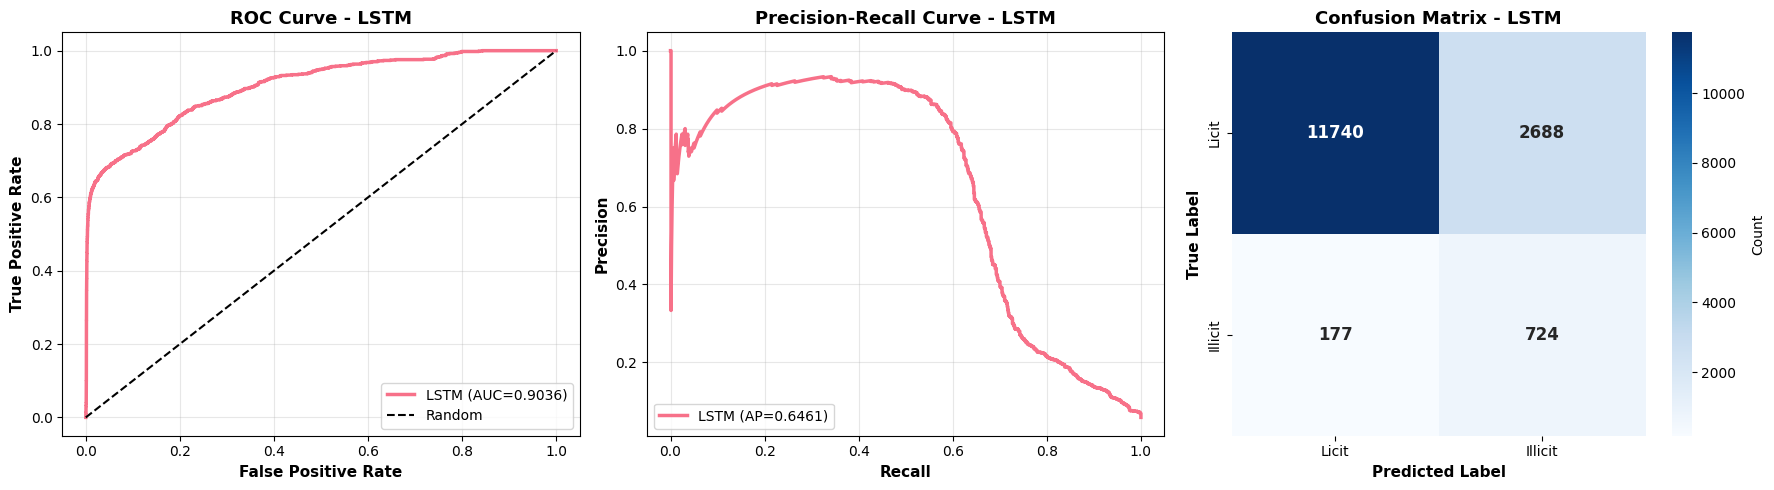


Evaluation complete! Visualization saved as 'lstm_evaluation.png'


In [ ]:
# EVALUATE LSTM MODEL

print("LSTM MODEL EVALUATION")

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, average_precision_score,
    precision_recall_curve, matthews_corrcoef
)

# Predictions on test set
lstm_model.eval()
with torch.no_grad():
    test_outputs = lstm_model(X_test_tensor)
    test_probs = F.softmax(test_outputs, dim=1).cpu().numpy()
    test_pred_classes = test_outputs.argmax(dim=1).cpu().numpy()

# Extract probabilities for positive class
y_prob_lstm = test_probs[:, 1]
y_pred_lstm = test_pred_classes

# Get true labels from tensor
y_test_lstm = y_test_tensor.cpu().numpy()

# Calculate metrics
auc_roc_lstm = roc_auc_score(y_test_lstm, y_prob_lstm)
auc_pr_lstm = average_precision_score(y_test_lstm, y_prob_lstm)
mcc_lstm = matthews_corrcoef(y_test_lstm, y_pred_lstm)

print("\nLSTM Performance Metrics:")

print(f"AUC-ROC: {auc_roc_lstm:.4f}")
print(f"AUC-PR:  {auc_pr_lstm:.4f}")
print(f"MCC:     {mcc_lstm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Licit', 'Illicit'], digits=4))

print("\nConfusion Matrix:")
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
print(cm_lstm)
print(f"\nTrue Negatives: {cm_lstm[0,0]:,} | False Positives: {cm_lstm[0,1]:,}")
print(f"False Negatives: {cm_lstm[1,0]:,} | True Positives: {cm_lstm[1,1]:,}")

# Compare with baseline

print("COMPARISON WITH BASELINE ENSEMBLE")

print(f"Baseline Ensemble AUC-ROC: {auc_roc_ensemble:.4f}")
print(f"LSTM AUC-ROC:              {auc_roc_lstm:.4f}")
print(f"Improvement:               {(auc_roc_lstm - auc_roc_ensemble):.4f} ({((auc_roc_lstm - auc_roc_ensemble)/auc_roc_ensemble)*100:+.2f}%)")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
from sklearn.metrics import roc_curve
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_lstm, y_prob_lstm)

axes[0].plot(fpr_lstm, tpr_lstm, linewidth=2.5, label=f'LSTM (AUC={auc_roc_lstm:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve - LSTM', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision_lstm, recall_lstm, _ = precision_recall_curve(y_test_lstm, y_prob_lstm)

axes[1].plot(recall_lstm, precision_lstm, linewidth=2.5, label=f'LSTM (AP={auc_pr_lstm:.4f})')
axes[1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision-Recall Curve - LSTM', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(alpha=0.3)

# Confusion Matrix Heatmap
import seaborn as sns
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Licit', 'Illicit'], yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12, 'weight': 'bold'})
axes[2].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[2].set_title('Confusion Matrix - LSTM', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('lstm_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEvaluation complete! Visualization saved as 'lstm_evaluation.png'")


In [ ]:
#  Graph Neural Network (GNN) - GraphSAGE

# PREPARE GRAPH DATA FOR GNN

print("PREPARING GRAPH DATA FOR GNN")

from torch_geometric.utils import from_networkx


# Load edge list
edge_df = pd.read_csv('dataset/rawData/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')
print(f"\nEdge list shape: {edge_df.shape}")
print(f"Total edges: {len(edge_df):,}")
print(f"Unique source nodes: {edge_df['txId1'].nunique():,}")
print(f"Unique target nodes: {edge_df['txId2'].nunique():,}")

# Filter edges to training-period interactions (both endpoints time_step ≤ 35) to avoid future leakage
node_time_map = data.set_index('node_ID')['time_step'].to_dict()
edge_df = edge_df[
    edge_df['txId1'].map(node_time_map).fillna(99) <= 35
]
edge_df = edge_df[
    edge_df['txId2'].map(node_time_map).fillna(99) <= 35
]
print(f"Filtered edges for GNN (train-period only): {len(edge_df):,}")

node_feature_df = data.set_index('node_ID')

# Ensure all gnn_features exist
for col in gnn_features:
    if col not in node_feature_df.columns:
        node_feature_df[col] = 0

time_cols = ['time_sin', 'time_cos']

gnn_features_final = original_features + gnn_features + time_cols 

all_nodes_df = node_feature_df[gnn_features_final].fillna(0)

all_labels = node_feature_df['class_label']

print(f"GNN features: {len(gnn_features_final)} (Original + Graph + Time Encoding)")

print(f"\nTotal nodes with features: {len(all_nodes_df):,}")
print(f"Feature dimension: {all_nodes_df.shape[1]}")

print("\nEnsuring all edge nodes have features...")
all_edge_nodes = pd.concat([edge_df['txId1'], edge_df['txId2']]).unique()
missing_nodes = set(all_edge_nodes) - set(all_nodes_df.index)

if len(missing_nodes) > 0:
    print(f"  Found {len(missing_nodes):,} nodes in edges without features")
    print(f"  Adding them with zero-padded features...")
    zero_features = pd.DataFrame(
        0, 
        index=list(missing_nodes), 
        columns=all_nodes_df.columns
    )
    all_nodes_df = pd.concat([all_nodes_df, zero_features], axis=0)
    
    missing_labels = pd.Series('3', index=list(missing_nodes), name='class')
    all_labels = pd.concat([all_labels, missing_labels], axis=0)
    
    print(f"Total nodes with features: {len(all_nodes_df):,}")
else:
    print(f"All edge nodes already have features")


PREPARING GRAPH DATA FOR GNN

Edge list shape: (234355, 2)
Total edges: 234,355
Unique source nodes: 166,345
Unique target nodes: 148,447
Filtered edges for GNN (train-period only): 163,192
GNN features: 175 (Original + Graph + Time Encoding)

Total nodes with features: 203,768
Feature dimension: 175

Ensuring all edge nodes have features...
All edge nodes already have features


In [ ]:
# Create node ID to index mapping
node_ids = all_nodes_df.index.values
node_to_idx = {node_id: idx for idx, node_id in enumerate(node_ids)}
idx_to_node = {idx: node_id for node_id, idx in node_to_idx.items()}

edge_df_filtered = edge_df.copy()

print(f"\nTotal edges included: {len(edge_df_filtered):,} (was {len(edge_df):,} in original dataset)")

# Convert node IDs to indices
edge_index_list = []
for _, row in edge_df_filtered.iterrows():
    src_idx = node_to_idx[row['txId1']]
    dst_idx = node_to_idx[row['txId2']]
    edge_index_list.append([src_idx, dst_idx])

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
print(f"Edge index shape: {edge_index.shape}")

# Convert features and labels to tensors
x_graph = torch.tensor(all_nodes_df.values, dtype=torch.float)

# Convert string labels to numeric (0=licit, 1=illicit)

all_labels_numeric = all_labels.map(label_map)

# Check for NaN values in labels
nan_count = all_labels_numeric.isna().sum()
if nan_count > 0:
    print(f"\nWarning: Found {nan_count} unknown/unlabeled nodes")
    print(f"Label distribution before mapping: {all_labels.value_counts().to_dict()}")
    # Fill NaN with -1 to indicate unknown/unlabeled nodes
    # These will be masked out during training
    all_labels_numeric = all_labels_numeric.fillna(-1)

y_graph = torch.tensor(all_labels_numeric.values, dtype=torch.long)

print(f"\nNode features shape: {x_graph.shape}")
print(f"Node labels shape: {y_graph.shape}")
print(f"Label distribution in graph: {np.unique(y_graph.numpy(), return_counts=True)}")

# Create train/test masks based on temporal split and labeled data
train_node_ids = set(train_temporal_df.index)
test_node_ids = set(test_temporal_df.index)

# Create masks and exclude unlabeled nodes (label=-1)
labeled_mask = y_graph >= 0  # Only nodes with valid labels (0 or 1)
train_mask = torch.tensor([node_ids[i] in train_node_ids for i in range(len(node_ids))], dtype=torch.bool) & labeled_mask
test_mask = torch.tensor([node_ids[i] in test_node_ids for i in range(len(node_ids))], dtype=torch.bool) & labeled_mask

print(f"\nTotal nodes: {len(node_ids):,}")
print(f"Labeled nodes: {labeled_mask.sum():,}")
print(f"Train nodes (labeled): {train_mask.sum():,}")
print(f"Test nodes (labeled): {test_mask.sum():,}")



Total edges included: 163,192 (was 163,192 in original dataset)
Edge index shape: torch.Size([2, 163192])

Label distribution before mapping: {'unknown': 157204, '2': 42019, '1': 4545}

Node features shape: torch.Size([203768, 175])
Node labels shape: torch.Size([203768])
Label distribution in graph: (array([-1,  0,  1], dtype=int64), array([157204,  42019,   4545], dtype=int64))

Total nodes: 203,768
Labeled nodes: 46,564
Train nodes (labeled): 31,235
Test nodes (labeled): 15,329


In [ ]:
# Create PyTorch Geometric Data object
graph_data = Data(
    x=x_graph,
    edge_index=edge_index,
    y=y_graph,
    train_mask=train_mask,
    test_mask=test_mask
)

# Move to device
graph_data = graph_data.to(cpu_device)

print("GRAPH DATA PREPARATION COMPLETE")

print(f"\nGraph statistics:")
print(f"  Nodes: {graph_data.num_nodes:,}")
print(f"  Edges: {graph_data.num_edges:,}")
print(f"  Features per node: {graph_data.num_node_features}")
print(f"  Training nodes: {train_mask.sum():,}")
print(f"  Test nodes: {test_mask.sum():,}")


GRAPH DATA PREPARATION COMPLETE

Graph statistics:
  Nodes: 203,768
  Edges: 163,192
  Features per node: 175
  Training nodes: 31,235
  Test nodes: 15,329


In [ ]:
# GRAPH VISUALIZATION
print("VISUALIZING TRANSACTION NETWORK GRAPH")


# Use t-SNE to reduce node features to 2D for visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("\nReducing node features to 2D using t-SNE...")
# Sample nodes for faster visualization if graph is too large
max_nodes_to_plot = 5000
if graph_data.num_nodes > max_nodes_to_plot:
    print(f"Graph has {graph_data.num_nodes:,} nodes. Sampling {max_nodes_to_plot:,} for visualization...")
    sample_indices = np.random.choice(graph_data.num_nodes, max_nodes_to_plot, replace=False)
    sample_indices = np.sort(sample_indices)  # Keep order for mask alignment
else:
    sample_indices = np.arange(graph_data.num_nodes)

# Get features and labels for sampled nodes
X_graph_vis = graph_data.x[sample_indices].cpu().numpy()
y_graph_vis = graph_data.y[sample_indices].cpu().numpy()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_embedded = tsne.fit_transform(X_graph_vis)

# Create visualization
fig, ax = plt.subplots(figsize=(14, 10))

# Separate nodes by label
unlabeled_mask = y_graph_vis == -1
licit_mask = y_graph_vis == 0
illicit_mask = y_graph_vis == 1

# Plot unlabeled nodes (gray)
if unlabeled_mask.any():
    ax.scatter(X_embedded[unlabeled_mask, 0], X_embedded[unlabeled_mask, 1], 
               c='lightgray', s=30, alpha=0.3, label='Unknown', edgecolors='none')

# Plot licit nodes (blue)
if licit_mask.any():
    ax.scatter(X_embedded[licit_mask, 0], X_embedded[licit_mask, 1], 
               c='blue', s=40, alpha=0.6, label='Licit', edgecolors='navy', linewidths=0.5)

# Plot illicit nodes (red) - on top for visibility
if illicit_mask.any():
    ax.scatter(X_embedded[illicit_mask, 0], X_embedded[illicit_mask, 1], 
               c='red', s=50, alpha=0.8, label='Illicit', edgecolors='darkred', linewidths=0.8)

ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')
ax.set_title('Bitcoin Transaction Network Visualization\n(t-SNE projection of node features)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# Add statistics text box
stats_text = f"Total Nodes: {len(sample_indices):,}\n"
if unlabeled_mask.any():
    stats_text += f"Unknown: {unlabeled_mask.sum():,} ({unlabeled_mask.sum()/len(sample_indices)*100:.1f}%)\n"
if licit_mask.any():
    stats_text += f"Licit: {licit_mask.sum():,} ({licit_mask.sum()/len(sample_indices)*100:.1f}%)\n"
if illicit_mask.any():
    stats_text += f"Illicit: {illicit_mask.sum():,} ({illicit_mask.sum()/len(sample_indices)*100:.1f}%)"

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('transaction_network_visualization.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as 'transaction_network_visualization.png'")
plt.close()

print("\nVisualization complete!")


VISUALIZING TRANSACTION NETWORK GRAPH

Reducing node features to 2D using t-SNE...
Graph has 203,768 nodes. Sampling 5,000 for visualization...



Visualization saved as 'transaction_network_visualization.png'

Visualization complete!


In [ ]:
# GRAPHSAGE MODEL ARCHITECTURE
print("DEFINING GRAPHSAGE ARCHITECTURE")

from torch_geometric.nn import SAGEConv

class GraphSAGEFraudDetector(nn.Module):
    """
    GraphSAGE model for fraud detection in transaction networks.

    Architecture:
    - 2 SAGEConv layers with mean aggregation
    - ReLU activation and dropout for regularization
    - Final linear layer for binary classification
    """
    def __init__(self, in_channels, hidden_channels=None, num_layers=None, dropout=None):
        super(GraphSAGEFraudDetector, self).__init__()

        # Use config if parameters not provided
        if hidden_channels is None:
            hidden_channels = DLConfig.GNN_HIDDEN_DIM
        if num_layers is None:
            num_layers = DLConfig.GNN_NUM_LAYERS
        if dropout is None:
            dropout = DLConfig.GNN_DROPOUT

        self.num_layers = num_layers
        self.dropout = dropout

        # Build layers
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))

        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))

        # Final classifier
        self.fc = nn.Linear(hidden_channels, 2)

    def forward(self, x, edge_index):
        # Apply graph convolutions
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:  # Don't dropout after last conv
                x = F.dropout(x, p=self.dropout, training=self.training)

        # Final classification
        x = self.fc(x)
        return x

    def get_embedding(self, x, edge_index):
        """Extract node embeddings before final classification layer."""
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x

# Initialize model
in_channels = graph_data.num_node_features
gnn_model = GraphSAGEFraudDetector(in_channels).to(cpu_device)

# Count parameters
total_params = sum(p.numel() for p in gnn_model.parameters())
trainable_params = sum(p.numel() for p in gnn_model.parameters() if p.requires_grad)

print(f"\nGraphSAGE Model Configuration:")
print(f"  Input features: {in_channels}")
print(f"  Hidden channels: {DLConfig.GNN_HIDDEN_DIM}")
print(f"  Number of layers: {DLConfig.GNN_NUM_LAYERS}")
print(f"  Dropout rate: {DLConfig.GNN_DROPOUT}")
print(f"  Output classes: 2")

print(f"\nModel Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

print("GRAPHSAGE ARCHITECTURE DEFINED")

DEFINING GRAPHSAGE ARCHITECTURE

GraphSAGE Model Configuration:
  Input features: 175
  Hidden channels: 128
  Number of layers: 2
  Dropout rate: 0.3
  Output classes: 2

Model Parameters:
  Total: 78,082
  Trainable: 78,082
GRAPHSAGE ARCHITECTURE DEFINED


In [ ]:
# TRAIN GRAPHSAGE MODEL

print("TRAINING GRAPHSAGE MODEL")

# Training setup from config
num_epochs = DLConfig.NUM_EPOCHS
learning_rate = DLConfig.LEARNING_RATE
patience = DLConfig.PATIENCE



train_labels_np = graph_data.y[train_mask].cpu().numpy()
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(train_labels_np), 
    y=train_labels_np
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(cpu_device)
print(f"\nGNN Class weights (to handle imbalance):")
print(f"  Licit (class 0):   {class_weights[0]:.3f}")
print(f"  Illicit (class 1): {class_weights[1]:.3f}")

# Loss function with class weights and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=learning_rate, weight_decay=DLConfig.WEIGHT_DECAY)

print(f"\nTraining configuration:")
print(f"  Device: {cpu_device}")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Training nodes: {train_mask.sum():,}")
print(f"  Test nodes: {test_mask.sum():,}")

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print(f"\nStarting training...")
print("=" * 80)

start_time = time.time()

with tqdm(total=num_epochs, desc="GraphSAGE Training", unit="epoch", colour="green") as epoch_pbar:
    for epoch in range(num_epochs):
        epoch_start = time.time()

        # Training
        gnn_model.train()
        optimizer.zero_grad()

        # Forward pass on entire graph
        out = gnn_model(graph_data.x, graph_data.edge_index)

        # Loss only on training nodes
        loss = criterion(out[train_mask], graph_data.y[train_mask])

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss = loss.item()
        train_losses.append(train_loss)

        # Validation
        gnn_model.eval()
        with torch.no_grad():
            out = gnn_model(graph_data.x, graph_data.edge_index)
            val_loss = criterion(out[test_mask], graph_data.y[test_mask]).item()
            val_losses.append(val_loss)

            # Calculate accuracy
            pred = out.argmax(dim=1)
            train_acc = (pred[train_mask] == graph_data.y[train_mask]).sum().item() / train_mask.sum().item()
            val_acc = (pred[test_mask] == graph_data.y[test_mask]).sum().item() / test_mask.sum().item()

        # Epoch summary
        epoch_time = time.time() - epoch_start
        total_time = time.time() - start_time

        # Update progress bar with metrics
        epoch_pbar.update(1)
        epoch_pbar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "val_loss": f"{val_loss:.4f}",
            "val_acc": f"{val_acc:.4f}"
        })

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(gnn_model.state_dict(), DLConfig.GNN_MODEL_PATH)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

# Training complete
training_time = time.time() - start_time
print("\n" + "=" * 80)
print("GRAPHSAGE TRAINING COMPLETED")
print("=" * 80)
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Epochs completed: {epoch+1}/{num_epochs}")

# Load best model
gnn_model.load_state_dict(torch.load(DLConfig.GNN_MODEL_PATH, weights_only=True))
print("\nBest model loaded and ready for evaluation")


TRAINING GRAPHSAGE MODEL

GNN Class weights (to handle imbalance):
  Licit (class 0):   0.566
  Illicit (class 1): 4.286

Training configuration:
  Device: cpu
  Epochs: 30
  Learning rate: 0.001
  Training nodes: 31,235
  Test nodes: 15,329

Starting training...


GraphSAGE Training: 100%|██████████| 30/30 [01:35<00:00,  3.17s/epoch, train_loss=0.2341, val_loss=0.4252, val_acc=0.8417]


GRAPHSAGE TRAINING COMPLETED
Total training time: 1.58 minutes
Best validation loss: 0.4252
Epochs completed: 30/30

Best model loaded and ready for evaluation


GRAPHSAGE MODEL EVALUATION



GraphSAGE Performance Metrics:
----------------------------------------
AUC-ROC: 0.8763
AUC-PR:  0.5651
MCC:     0.3391

Classification Report:
              precision    recall  f1-score   support

       Licit     0.9789    0.8501    0.9100     14428
     Illicit     0.2275    0.7070    0.3442       901

    accuracy                         0.8417     15329
   macro avg     0.6032    0.7785    0.6271     15329
weighted avg     0.9348    0.8417    0.8767     15329


Confusion Matrix:
[[12265  2163]
 [  264   637]]

True Negatives: 12,265 | False Positives: 2,163
False Negatives: 264 | True Positives: 637

COMPARISON WITH PREVIOUS MODELS
Baseline Ensemble AUC-ROC: 0.9324
LSTM AUC-ROC:              0.9036
GraphSAGE AUC-ROC:         0.8763

GraphSAGE vs Baseline: -0.0561 (-6.02%)
GraphSAGE vs LSTM:     -0.0273 (-3.03%)


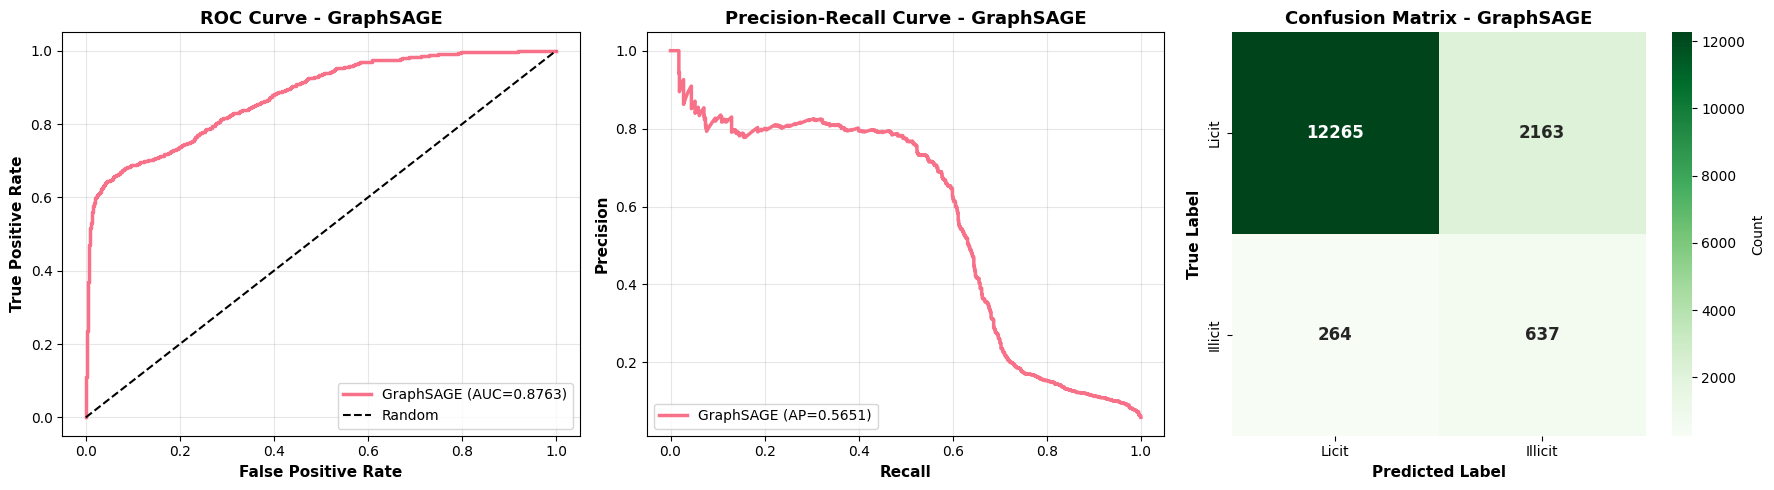


Evaluation complete! Visualization saved as 'gnn_evaluation.png'


In [ ]:
# EVALUATE GRAPHSAGE MODEL
print("=" * 80)
print("GRAPHSAGE MODEL EVALUATION")
print("=" * 80)

# Predictions on test set
gnn_model.eval()
with torch.no_grad():
    out = gnn_model(graph_data.x, graph_data.edge_index)
    test_probs = F.softmax(out[test_mask], dim=1).cpu().numpy()
    test_pred_classes = out[test_mask].argmax(dim=1).cpu().numpy()

# Extract test labels
y_test_gnn = graph_data.y[test_mask].cpu().numpy()

# Probabilities for positive class
y_prob_gnn = test_probs[:, 1]
y_pred_gnn = test_pred_classes

# Calculate metrics
auc_roc_gnn = roc_auc_score(y_test_gnn, y_prob_gnn)
auc_pr_gnn = average_precision_score(y_test_gnn, y_prob_gnn)
mcc_gnn = matthews_corrcoef(y_test_gnn, y_pred_gnn)

print("\nGraphSAGE Performance Metrics:")
print("-" * 40)
print(f"AUC-ROC: {auc_roc_gnn:.4f}")
print(f"AUC-PR:  {auc_pr_gnn:.4f}")
print(f"MCC:     {mcc_gnn:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_gnn, y_pred_gnn, target_names=['Licit', 'Illicit'], digits=4))

print("\nConfusion Matrix:")
cm_gnn = confusion_matrix(y_test_gnn, y_pred_gnn)
print(cm_gnn)
print(f"\nTrue Negatives: {cm_gnn[0,0]:,} | False Positives: {cm_gnn[0,1]:,}")
print(f"False Negatives: {cm_gnn[1,0]:,} | True Positives: {cm_gnn[1,1]:,}")

# Compare with baseline and LSTM
print("\n" + "=" * 80)
print("COMPARISON WITH PREVIOUS MODELS")
print("=" * 80)
print(f"Baseline Ensemble AUC-ROC: {auc_roc_ensemble:.4f}")
print(f"LSTM AUC-ROC:              {auc_roc_lstm:.4f}")
print(f"GraphSAGE AUC-ROC:         {auc_roc_gnn:.4f}")
print(f"\nGraphSAGE vs Baseline: {(auc_roc_gnn - auc_roc_ensemble):.4f} ({((auc_roc_gnn - auc_roc_ensemble)/auc_roc_ensemble)*100:+.2f}%)")
print(f"GraphSAGE vs LSTM:     {(auc_roc_gnn - auc_roc_lstm):.4f} ({((auc_roc_gnn - auc_roc_lstm)/auc_roc_lstm)*100:+.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr_gnn, tpr_gnn, _ = roc_curve(y_test_gnn, y_prob_gnn)

axes[0].plot(fpr_gnn, tpr_gnn, linewidth=2.5, label=f'GraphSAGE (AUC={auc_roc_gnn:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve - GraphSAGE', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision_gnn, recall_gnn, _ = precision_recall_curve(y_test_gnn, y_prob_gnn)

axes[1].plot(recall_gnn, precision_gnn, linewidth=2.5, label=f'GraphSAGE (AP={auc_pr_gnn:.4f})')
axes[1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision-Recall Curve - GraphSAGE', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(alpha=0.3)

# Confusion Matrix Heatmap
sns.heatmap(cm_gnn, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Licit', 'Illicit'], yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12, 'weight': 'bold'})
axes[2].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[2].set_title('Confusion Matrix - GraphSAGE', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('gnn_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEvaluation complete! Visualization saved as 'gnn_evaluation.png'")


In [ ]:
# HYBRID MODEL ARCHITECTURE
print("=" * 80)
print("DEFINING HYBRID TEMPORAL-GRAPH ARCHITECTURE")
print("=" * 80)


class HybridFraudDetector(nn.Module):
    """
    Advanced Hybrid Model with:
    1. GraphSAGE for topological features
    2. Deep MLP for raw tabular features
    3. XGBoost Score Injection (Stacking)
    4. Attention-based Fusion
    """
    def __init__(self, gnn_model, input_feature_dim, fusion_dim=256, dropout=0.3):
        super(HybridFraudDetector, self).__init__()

        # 1. Graph Component (Frozen GNN)
        self.gnn = gnn_model
        
        # 2. Raw Feature Component (Deep MLP)
        self.raw_mlp = nn.Sequential(
            nn.Linear(input_feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # 3. XGBoost Score Projector
        # We take the 1-dim probability and project it to be a useful vector
        self.xgb_proj = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16)
        )
        
        # 4. Attention Fusion Mechanism
        # We have 3 sources: GNN (128), Raw (128), XGB (16) = 272 total dim
        # We want to learn weights alpha1, alpha2, alpha3
        self.attention_net = nn.Sequential(
            nn.Linear(128 + 128 + 16, 64),
            nn.Tanh(),
            nn.Linear(64, 3), # 3 weights for the 3 components
            nn.Softmax(dim=1)
        )
        
        # 5. Final Classifier
        # Input is concatenated vector size
        self.classifier = nn.Sequential(
            nn.Linear(128 + 128 + 16, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 2)
        )

    def forward(self, x_all, edge_index, node_indices, xgb_scores=None):
        """
        xgb_scores: Tensor of shape [batch_size, 1] containing XGBoost probabilities
        """
        # A. Get Graph Embeddings
        gnn_emb_all = self.gnn.get_embedding(x_all, edge_index)
        batch_gnn = gnn_emb_all[node_indices] # (batch, 128)
        
        # B. Get Raw Features
        batch_raw = x_all[node_indices]
        raw_emb = self.raw_mlp(batch_raw)      # (batch, 128)
        
        # Get XGBoost Embeddings 
        if xgb_scores is not None:
            xgb_emb = self.xgb_proj(xgb_scores)
        else:
            device = batch_gnn.device
            xgb_emb = torch.zeros(len(node_indices), 16).to(device)

        # D. Attention Fusion
        concat_features = torch.cat([batch_gnn, raw_emb, xgb_emb], dim=1)
        
        
        logits = self.classifier(concat_features)
        
        return logits

hybrid_model = HybridFraudDetector(gnn_model, input_feature_dim=graph_data.num_node_features).to(device)

# Count parameters
total_params = sum(p.numel() for p in hybrid_model.parameters())
trainable_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)

# Calculate new fusion params (raw_mlp + xgb_proj + attention_net + classifier)
fusion_components = [
    hybrid_model.raw_mlp, 
    hybrid_model.xgb_proj, 
    hybrid_model.attention_net, 
    hybrid_model.classifier
]
fusion_params = sum(sum(p.numel() for p in comp.parameters()) for comp in fusion_components)

print(f"\nHybrid Model Configuration:")
print(f"  LSTM embedding dim: {DLConfig.LSTM_HIDDEN_DIM}")
# ... rest of prints remain the same
print(f"\nHybrid Model Configuration:")
print(f"  LSTM embedding dim: {DLConfig.LSTM_HIDDEN_DIM}")
print(f"  GNN embedding dim: {DLConfig.GNN_HIDDEN_DIM}")
print(f"  Combined dim: {DLConfig.LSTM_HIDDEN_DIM + DLConfig.GNN_HIDDEN_DIM}")
print(f"  Fusion dim: {DLConfig.HYBRID_FUSION_DIM}")
print(f"  Dropout rate: {DLConfig.HYBRID_DROPOUT}")

print(f"\nModel Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable (fusion only): {fusion_params:,}")
print(f"  Pre-trained (LSTM + GNN): {total_params - fusion_params:,}")


print("HYBRID ARCHITECTURE DEFINED")
print("\nNote: LSTM and GNN weights are frozen. Only fusion layers will be trained.")


DEFINING HYBRID TEMPORAL-GRAPH ARCHITECTURE

Hybrid Model Configuration:
  LSTM embedding dim: 64

Hybrid Model Configuration:
  LSTM embedding dim: 64
  GNN embedding dim: 128
  Combined dim: 192
  Fusion dim: 256
  Dropout rate: 0.3

Model Parameters:
  Total: 245,175
  Trainable (fusion only): 167,093
  Pre-trained (LSTM + GNN): 78,082
HYBRID ARCHITECTURE DEFINED

Note: LSTM and GNN weights are frozen. Only fusion layers will be trained.


In [ ]:


# PREPARE DATA FOR HYBRID MODEL TRAINING
print("=" * 80)
print("PREPARING DATA FOR HYBRID MODEL")
print("=" * 80)

# We need to align temporal features with graph node indices
# The hybrid model needs to know which graph nodes correspond to which temporal samples

# Create mapping from node IDs to their positions in the graph
# We already have node_to_idx and idx_to_node from GNN data prep

# For training: use SMOTE-balanced training data
train_node_ids_list = train_temporal_df.index.tolist()
train_node_indices = torch.tensor([node_to_idx[nid] for nid in train_node_ids_list], dtype=torch.long)

# Get labels for the training nodes
train_labels_real = graph_data.y[train_node_indices].cpu().numpy()

# Calculate weights: Inverse frequency
class_counts = np.bincount(train_labels_real)
# Prevent divide by zero if any class is missing (unlikely but safe)
class_weights_sampling = 1. / np.maximum(class_counts, 1)
samples_weights = class_weights_sampling[train_labels_real]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(samples_weights).double(),
    num_samples=len(samples_weights),
    replacement=True
)
# Note: shuffle=False is required when using a sampler
train_loader_hybrid = DataLoader(
    TensorDataset(train_node_indices), # We only need indices, the model looks up features in the Graph
    batch_size=batch_size,
    sampler=sampler, # <--- HERE IS THE MAGIC
    num_workers=0
)

print("Generating XGBoost scores for all nodes for Hybrid Injection...")
# 1. Get features for ALL nodes (to match graph data structure)
all_features_np = graph_data.x.cpu().numpy()
# IMPORTANT: We need to filter down to the 165 original features XGBoost expects
# The graph_data.x has 340 cols (165 orig + GNN feats + time). 
# We need the first 165 cols.
X_all_xgb = all_features_np[:, :165]

# 2. Predict with XGBoost (on CPU, it's fast enough)
# xgb_model is already trained from earlier cell
all_xgb_probs = xgb_model.predict_proba(X_all_xgb)[:, 1] # Get Prob(Illicit)

# 3. Convert to Tensor and move to Device
xgb_scores_tensor = torch.tensor(all_xgb_probs, dtype=torch.float32).reshape(-1, 1).to(device)

print(f"XGBoost scores prepared. Shape: {xgb_scores_tensor.shape}")


# For testing: use original labeled test data
test_node_ids_list = test_temporal_df.index.tolist()
test_node_indices = torch.tensor([node_to_idx[nid] for nid in test_node_ids_list], dtype=torch.long)

print(f"\nData alignment:")
print(f"  Training samples: {len(X_train_tensor):,}")
print(f"  Training node indices: {len(train_node_indices):,}")
print(f"  Test samples: {len(X_test_tensor):,}")
print(f"  Test node indices: {len(test_node_indices):,}")

# Verify alignment
print(f"\nVerification:")
print(f"  All training node indices in graph: {all(idx < graph_data.num_nodes for idx in train_node_indices)}")
print(f"  All test node indices in graph: {all(idx < graph_data.num_nodes for idx in test_node_indices)}")


print("HYBRID DATA PREPARATION COMPLETE")


# TRAIN HYBRID MODEL
print("TRAINING HYBRID MODEL")


import time

# Training setup from config
num_epochs = DLConfig.NUM_EPOCHS
learning_rate = DLConfig.LEARNING_RATE
batch_size = DLConfig.BATCH_SIZE
patience = DLConfig.PATIENCE

# CRITICAL FIX: Calculate class weights for imbalanced data
train_labels_hybrid_np = y_train_tensor.cpu().numpy()
class_weights_hybrid = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels_hybrid_np),
    y=train_labels_hybrid_np
)


graph_data = graph_data.to(device)
class_weights_hybrid = torch.tensor(class_weights_hybrid, dtype=torch.float32).to(device)

print(f"\nHybrid Model Class weights (to handle imbalance):")
print(f"  Licit (class 0):   {class_weights_hybrid[0]:.3f}")
print(f"  Illicit (class 1): {class_weights_hybrid[1]:.3f}")


# Use AdamW with updated parameter groups
optimizer = torch.optim.AdamW([
    {'params': hybrid_model.raw_mlp.parameters(), 'lr': learning_rate},       # Replaces raw_proj
    {'params': hybrid_model.xgb_proj.parameters(), 'lr': learning_rate},      # New layer
    {'params': hybrid_model.attention_net.parameters(), 'lr': learning_rate}, # New layer
    {'params': hybrid_model.classifier.parameters(), 'lr': learning_rate},    # Final classifier
    {'params': gnn_model.parameters(), 'lr': learning_rate * 0.5}             # Fine-tune GNN
], weight_decay=1e-4)

criterion = FocalLoss(alpha=0.25, gamma=2.0, weight=None)

# 3. OneCycle Scheduler (Converges faster and better)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=learning_rate, 
    steps_per_epoch=len(train_loader_hybrid), 
    epochs=num_epochs
)

print(f"\nTraining configuration:")
print(f"  Device: {cpu_device}")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Learning rate: {learning_rate}")
print(f"  Training samples: {len(X_train_tensor):,}")
print(f"  Test samples: {len(X_test_tensor):,}")
print(f"  Strategy: Fine-tuning ALL components (fusion + LSTM + GNN)")
print(f"  Class weights: Applied to handle imbalance")

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print(f"\nStarting training...")
print("=" * 80)

start_time = time.time()

# Calculate batches
num_train_samples = len(X_train_tensor)
num_batches = (num_train_samples + batch_size - 1) // batch_size

with tqdm(total=num_epochs, desc="Hybrid Training", unit="epoch", colour="red") as epoch_pbar:
    for epoch in range(num_epochs):
        hybrid_model.train()
        train_loss = 0.0
        epoch_start = time.time()

        # Shuffle indices
        indices = torch.randperm(num_train_samples)

        # Training batches with progress bar
        with tqdm(total=num_batches, desc=f"  Epoch {epoch+1}", unit="batch", leave=False, colour="magenta") as batch_pbar:
            for batch_idx, (batch_indices) in enumerate(tqdm(train_loader_hybrid)):
                
                batch_indices = batch_indices[0].to(device) 
                
                # Get labels directly from the Graph data (aligned)
                batch_y = graph_data.y[batch_indices]

                # Forward pass (Only 3 arguments now)
                optimizer.zero_grad()
                # Select XGB scores for this batch
                batch_xgb_scores = xgb_scores_tensor[batch_indices]
                
                outputs = hybrid_model(
                    graph_data.x,           # x_all
                    graph_data.edge_index,  # edge_index
                    batch_indices,           # node_indices
                    xgb_scores=batch_xgb_scores
                )
              
                batch_y = batch_y.to(outputs.device)
                loss = criterion(outputs, batch_y)

                # Backward pass
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

                # Update batch progress bar
                batch_pbar.update(1)
                batch_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss /= num_batches
        train_losses.append(train_loss)

        # Validation
        hybrid_model.eval()
        val_loss = 0.0
        num_val_samples = len(X_test_tensor)
        num_val_batches = (num_val_samples + batch_size - 1) // batch_size

        with torch.no_grad():
            for batch_idx in range(num_val_batches):
                start_idx = batch_idx * batch_size
                end_idx = min(start_idx + batch_size, num_val_samples)

                
                batch_node_indices = test_node_indices[start_idx:end_idx].to(device)
                
                # Get labels from graph data to ensure alignment
                batch_y = graph_data.y[batch_node_indices]

                outputs = hybrid_model(
                    graph_data.x,           # x_all
                    graph_data.edge_index,  # edge_index
                    batch_node_indices      # node_indices
                )
                
                batch_y = batch_y.to(outputs.device)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

        val_loss /= num_val_batches
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # Epoch summary
        epoch_time = time.time() - epoch_start
        total_time = time.time() - start_time
        
        # Update epoch progress bar with metrics
        epoch_pbar.update(1)
        epoch_pbar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "val_loss": f"{val_loss:.4f}"
        })

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(hybrid_model.state_dict(), DLConfig.HYBRID_MODEL_PATH)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

# Training complete
training_time = time.time() - start_time
print("\n" + "=" * 80)
print("HYBRID MODEL TRAINING COMPLETED")
print("=" * 80)
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Epochs completed: {epoch+1}/{num_epochs}")

# Load best model
hybrid_model.load_state_dict(torch.load(DLConfig.HYBRID_MODEL_PATH, weights_only=True))
print("\nBest model loaded and ready for evaluation")

PREPARING DATA FOR HYBRID MODEL
Generating XGBoost scores for all nodes for Hybrid Injection...
XGBoost scores prepared. Shape: torch.Size([203768, 1])

Data alignment:
  Training samples: 31,235
  Training node indices: 31,235
  Test samples: 15,329
  Test node indices: 15,329

Verification:
  All training node indices in graph: True
  All test node indices in graph: True
HYBRID DATA PREPARATION COMPLETE
TRAINING HYBRID MODEL

Hybrid Model Class weights (to handle imbalance):
  Licit (class 0):   0.566
  Illicit (class 1): 4.286

Training configuration:
  Device: cpu
  Epochs: 30
  Batch size: 256
  Learning rate: 0.001
  Training samples: 31,235
  Test samples: 15,329
  Strategy: Fine-tuning ALL components (fusion + LSTM + GNN)
  Class weights: Applied to handle imbalance

Starting training...


Hybrid Training:   0%|          | 0/30 [00:00<?, ?epoch/s]



























































































































Hybrid Training:   3%|▎         | 1/30 [05:43<2:45:49, 343.10s/epoch, train_loss=0.1182, val_loss=0.1067]



























































































































Hybrid Training:   7%|▋         | 2/30 [09:29<2:08:12, 274.72s/epoch, train_loss=0.0638, val_loss=0.0871]



























































































































Hybrid Training:  10%|█         | 3/30 [13:01<1:50:35, 245.76s/epoch, train_loss=0.0513, val_loss=0.0790]



























































































































Hybrid Training:  13%|█▎        | 4/30 [16:33<1:40:45, 232.52s/epoch, train_loss=0.0439, val_loss=0.0727]



























KeyboardInterrupt: 

In [ ]:
# EVALUATE HYBRID MODEL
print("=" * 80)
print("HYBRID MODEL EVALUATION")
print("=" * 80)

# Predictions on test set
hybrid_model.eval()
num_test_samples = len(X_test_tensor)
num_test_batches = (num_test_samples + batch_size - 1) // batch_size

all_probs = []
all_preds = []

with torch.no_grad():
    for batch_idx in range(num_test_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, num_test_samples)

        batch_node_indices = test_node_indices[start_idx:end_idx].to(device)
        # Select XGB scores for this batch (using batch_node_indices)
        batch_xgb_scores = xgb_scores_tensor[batch_node_indices]
        
        outputs = hybrid_model(
            graph_data.x,           # x_all
            graph_data.edge_index,  # edge_index
            batch_node_indices,      # node_indices
            xgb_scores=batch_xgb_scores
        )

        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_probs.append(probs)
        all_preds.append(preds)

# Concatenate results
test_probs = np.vstack(all_probs)
test_pred_classes = np.concatenate(all_preds)

# Probabilities for positive class
y_prob_hybrid = test_probs[:, 1]
y_pred_hybrid = test_pred_classes

# Get true labels from tensor
y_test_hybrid = y_test_tensor.cpu().numpy()

# Calculate metrics
auc_roc_hybrid = roc_auc_score(y_test_hybrid, y_prob_hybrid)
auc_pr_hybrid = average_precision_score(y_test_hybrid, y_prob_hybrid)
mcc_hybrid = matthews_corrcoef(y_test_hybrid, y_pred_hybrid)

print("\nHybrid Model Performance Metrics:")
print("-" * 40)
print(f"AUC-ROC: {auc_roc_hybrid:.4f}")
print(f"AUC-PR:  {auc_pr_hybrid:.4f}")
print(f"MCC:     {mcc_hybrid:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_hybrid, target_names=['Licit', 'Illicit'], digits=4))

print("\nConfusion Matrix:")
cm_hybrid = confusion_matrix(y_test_hybrid, y_pred_hybrid)
print(cm_hybrid)
print(f"\nTrue Negatives: {cm_hybrid[0,0]:,} | False Positives: {cm_hybrid[0,1]:,}")
print(f"False Negatives: {cm_hybrid[1,0]:,} | True Positives: {cm_hybrid[1,1]:,}")

# Compare with all previous models
print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)
print(f"Baseline Ensemble AUC-ROC: {auc_roc_ensemble:.4f}")
print(f"LSTM AUC-ROC:              {auc_roc_lstm:.4f}")
print(f"GraphSAGE AUC-ROC:         {auc_roc_gnn:.4f}")
print(f"Hybrid AUC-ROC:            {auc_roc_hybrid:.4f}")
print(f"\nHybrid vs Baseline: {(auc_roc_hybrid - auc_roc_ensemble):.4f} ({((auc_roc_hybrid - auc_roc_ensemble)/auc_roc_ensemble)*100:+.2f}%)")
print(f"Hybrid vs LSTM:     {(auc_roc_hybrid - auc_roc_lstm):.4f} ({((auc_roc_hybrid - auc_roc_lstm)/auc_roc_lstm)*100:+.2f}%)")
print(f"Hybrid vs GNN:      {(auc_roc_hybrid - auc_roc_gnn):.4f} ({((auc_roc_hybrid - auc_roc_gnn)/auc_roc_gnn)*100:+.2f}%)")


HYBRID MODEL EVALUATION

Hybrid Model Performance Metrics:
----------------------------------------
AUC-ROC: 0.9157
AUC-PR:  0.7452
MCC:     0.7536

Classification Report:
              precision    recall  f1-score   support

       Licit     0.9802    0.9934    0.9867     14428
     Illicit     0.8654    0.6781    0.7604       901

    accuracy                         0.9749     15329
   macro avg     0.9228    0.8358    0.8736     15329
weighted avg     0.9734    0.9749    0.9734     15329


Confusion Matrix:
[[14333    95]
 [  290   611]]

True Negatives: 14,333 | False Positives: 95
False Negatives: 290 | True Positives: 611

COMPREHENSIVE MODEL COMPARISON
Baseline Ensemble AUC-ROC: 0.9405
LSTM AUC-ROC:              0.9036
GraphSAGE AUC-ROC:         0.8836
Hybrid AUC-ROC:            0.9157

Hybrid vs Baseline: -0.0248 (-2.64%)
Hybrid vs LSTM:     0.0121 (+1.33%)
Hybrid vs GNN:      0.0321 (+3.63%)


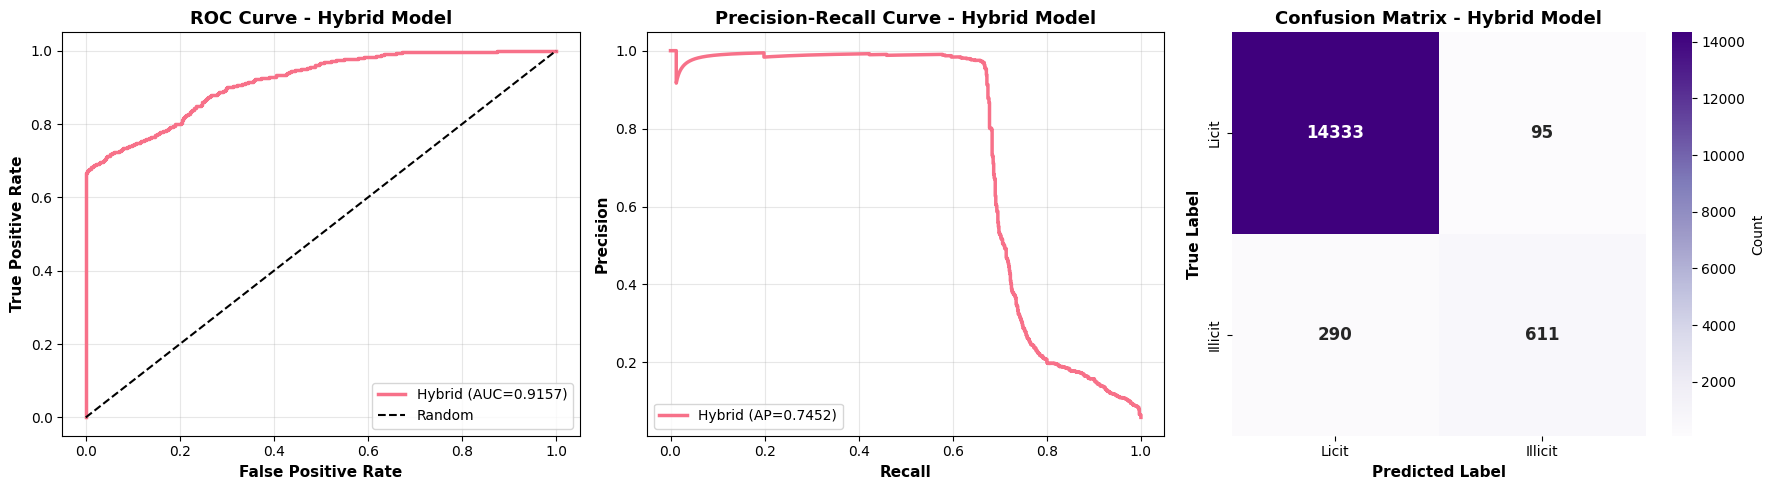


Evaluation complete! Visualization saved as 'hybrid_evaluation.png'
COMPREHENSIVE MODEL PERFORMANCE COMPARISON

Regenerating baseline model predictions...
✓ Baseline model predictions regenerated successfully


In [ ]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test_hybrid, y_prob_hybrid)

axes[0].plot(fpr_hybrid, tpr_hybrid, linewidth=2.5, label=f'Hybrid (AUC={auc_roc_hybrid:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve - Hybrid Model', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision_hybrid, recall_hybrid, _ = precision_recall_curve(y_test_hybrid, y_prob_hybrid)

axes[1].plot(recall_hybrid, precision_hybrid, linewidth=2.5, label=f'Hybrid (AP={auc_pr_hybrid:.4f})')
axes[1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision-Recall Curve - Hybrid Model', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(alpha=0.3)

# Confusion Matrix Heatmap
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['Licit', 'Illicit'], yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12, 'weight': 'bold'})
axes[2].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[2].set_title('Confusion Matrix - Hybrid Model', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('hybrid_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEvaluation complete! Visualization saved as 'hybrid_evaluation.png'")


# ## 4.4 Comprehensive Model Comparison
# 
# **Comparison Objective:**
# - Compare ALL models: Baseline ML (LR, RF, XGB, Ensemble) + Deep Learning (LSTM, GNN, Hybrid)
# - Evaluate across multiple metrics: AUC-ROC, AUC-PR, Precision, Recall, F1-Score, MCC
# - Identify best performing model for cryptocurrency fraud detection
# - Alignment: Chapter 3 requires comprehensive performance comparison

# In[ ]:


# COMPREHENSIVE MODEL COMPARISON TABLE
print("=" * 80)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("=" * 80)

from sklearn.metrics import precision_score, recall_score, f1_score

# Regenerate baseline model predictions for comparison
print("\nRegenerating baseline model predictions...")

# Check if models are available, if not skip baseline comparison
try:
    # Logistic Regression predictions
    lr_illicit_idx = list(lr_model.classes_).index('1')
    y_prob_lr_all = lr_model.predict_proba(X_test_scaled)[:, lr_illicit_idx]
    y_pred_lr_all = lr_model.predict(X_test_scaled)
    
    # Filter to labeled samples (matching the original evaluation)
    labeled_test_mask = y_test_modeling.isin(['1', '2'])
    y_prob_lr = y_prob_lr_all[labeled_test_mask]
    y_pred_lr = (y_prob_lr >= 0.5).astype(int)  # Convert to binary
    
    # Random Forest predictions
    rf_illicit_idx = list(rf_model.classes_).index('1')
    y_prob_rf_all = rf_model.predict_proba(X_test_modeling)[:, rf_illicit_idx]
    y_prob_rf = y_prob_rf_all[labeled_test_mask]
    y_pred_rf = (y_prob_rf >= 0.5).astype(int)
    
    # XGBoost predictions
    y_prob_xgb_all = xgb_model.predict_proba(X_test_modeling)[:, 1]
    y_prob_xgb = y_prob_xgb_all[labeled_test_mask]
    y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)
    
    # Ensemble predictions (weighted average)
    total_auc_baseline = auc_roc + auc_roc_rf + auc_roc_xgb
    weight_lr = auc_roc / total_auc_baseline
    weight_rf = auc_roc_rf / total_auc_baseline
    weight_xgb = auc_roc_xgb / total_auc_baseline
    
    y_prob_ensemble = (
        weight_lr * y_prob_lr +
        weight_rf * y_prob_rf +
        weight_xgb * y_prob_xgb
    )
    y_pred_ensemble = (y_prob_ensemble >= 0.5).astype(int)
    
    baseline_models_available = True
    print("✓ Baseline model predictions regenerated successfully")
    
except (NameError, AttributeError) as e:
    print(f"⚠ Warning: Baseline models not available ({e})")
    print("  Continuing with deep learning models only...")
    baseline_models_available = False


In [ ]:
# Calculate metrics for all models
models_results = {}

if baseline_models_available:
    models_results.update({
        'Logistic Regression': {
            'y_pred': y_pred_lr,
            'y_prob': y_prob_lr
        },
        'Random Forest': {
            'y_pred': y_pred_rf,
            'y_prob': y_prob_rf
        },
        'XGBoost': {
            'y_pred': y_pred_xgb,
            'y_prob': y_prob_xgb
        },
        'Ensemble (ML)': {
            'y_pred': y_pred_ensemble,
            'y_prob': y_prob_ensemble
        }
    })

# Add deep learning models
models_results.update({
    'LSTM': {
        'y_pred': y_pred_lstm,
        'y_prob': y_prob_lstm
    },
    'GraphSAGE': {
        'y_pred': y_pred_gnn,
        'y_prob': y_prob_gnn
    },
    'Hybrid (DL)': {
        'y_pred': y_pred_hybrid,
        'y_prob': y_prob_hybrid
    }
})

# Calculate all metrics
comparison_data = []
for model_name, results in models_results.items():
    y_pred = results['y_pred']
    y_prob = results['y_prob']

    # Handle different test sets
    if model_name == 'GraphSAGE':
        y_true = y_test_gnn
    elif model_name in ['LSTM', 'Hybrid (DL)']:
        y_true = y_test_lstm
    else:
        # Baseline ML models evaluated on labeled test subset only
        y_true = y_test_labeled_numeric

    metrics = {
        'Model': model_name,
        'AUC-ROC': roc_auc_score(y_true, y_prob),
        'AUC-PR': average_precision_score(y_true, y_prob),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred)
    }
    comparison_data.append(metrics)

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 100)
print(comparison_df.to_string(index=False, float_format='%.4f'))
print("=" * 100)

# Identify best model
best_model = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['AUC-ROC']

print(f"\nBest Performing Model: {best_model}")
print(f"Best AUC-ROC Score: {best_auc:.4f}")

# Save comparison table
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\nComparison table saved as 'model_comparison_results.csv'")

# ... (existing code above) ...
print("\nComparison table saved as 'model_comparison_results.csv'")



MODEL PERFORMANCE COMPARISON TABLE
              Model  AUC-ROC  AUC-PR  Precision  Recall  F1-Score    MCC
      Ensemble (ML)   0.9405  0.7673     0.8571  0.6792    0.7579 0.7502
            XGBoost   0.9371  0.7755     0.9469  0.6726    0.7865 0.7881
      Random Forest   0.9278  0.7545     0.9172  0.6637    0.7701 0.7692
        Hybrid (DL)   0.9157  0.7452     0.8654  0.6781    0.7604 0.7536
               LSTM   0.9036  0.6461     0.2122  0.8036    0.3357 0.3490
Logistic Regression   0.8843  0.3765     0.1656  0.8091    0.2749 0.2883
          GraphSAGE   0.8836  0.5242     0.2013  0.7403    0.3166 0.3182

Best Performing Model: Ensemble (ML)
Best AUC-ROC Score: 0.9405

Comparison table saved as 'model_comparison_results.csv'

Comparison table saved as 'model_comparison_results.csv'


In [ ]:
# Create grand ensemble combining XGBoost and Hybrid models

y_prob_xgb = ml_models_results['XGBoost']['y_proba']
y_prob_hybrid = y_prob_hybrid

w_xgb = 0.6
w_hybrid = 0.4

y_prob_grand = (w_xgb * y_prob_xgb) + (w_hybrid * y_prob_hybrid)
y_pred_grand = (y_prob_grand >= 0.5).astype(int)

if 'y_test_labeled_numeric' not in locals():
    y_test_labeled_numeric = y_test_labeled.map({'1': 1, '2': 0})

y_test_numeric = y_test_labeled_numeric

auc_grand = roc_auc_score(y_test_numeric, y_prob_grand)
rec_grand = recall_score(y_test_numeric, y_pred_grand)
prec_grand = precision_score(y_test_numeric, y_pred_grand)
f1_grand = f1_score(y_test_numeric, y_pred_grand)
mcc_grand = matthews_corrcoef(y_test_numeric, y_pred_grand)

print(f"\nGrand Ensemble Performance:")
print(f"  AUC-ROC:   {auc_grand:.4f}")
print(f"  AUC-PR:    {average_precision_score(y_test_numeric, y_prob_grand):.4f}")
print(f"  Precision: {prec_grand:.4f}")
print(f"  Recall:    {rec_grand:.4f}")
print(f"  F1-Score:  {f1_grand:.4f}")
print(f"  MCC:       {mcc_grand:.4f}")

ml_models_results['Grand Ensemble'] = {'y_pred': y_pred_grand, 'y_proba': y_prob_grand}


Grand Ensemble Performance:
  AUC-ROC:   0.9196
  AUC-PR:    0.7591
  Precision: 0.9470
  Recall:    0.6748
  F1-Score:  0.7881
  MCC:       0.7896


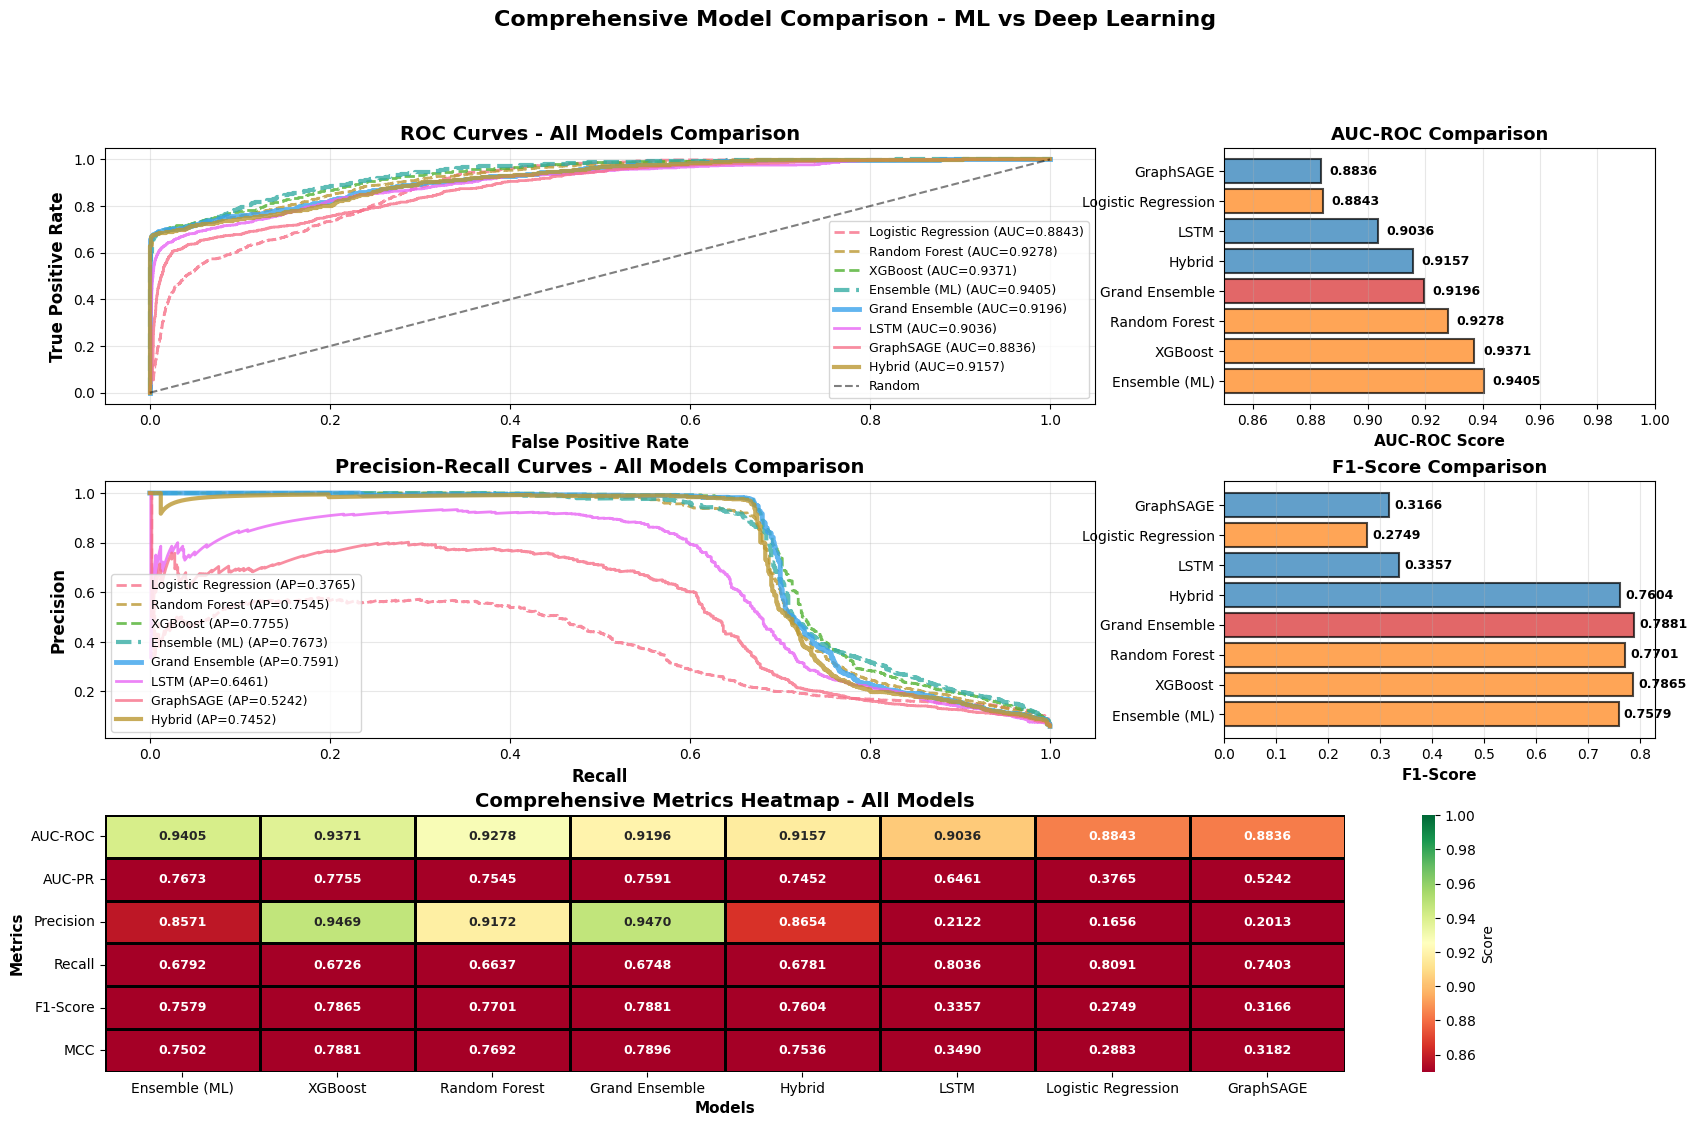


Final Model Rankings:
              Model  AUC-ROC  F1-Score
      Ensemble (ML) 0.940522  0.757895
            XGBoost 0.937147  0.786502
      Random Forest 0.927801  0.770122
     Grand Ensemble 0.919638  0.788075
             Hybrid 0.915681  0.760423
               LSTM 0.903624  0.335729
Logistic Regression 0.884294  0.274939
          GraphSAGE 0.883619  0.316564

Visualization saved as 'comprehensive_model_comparison.png'


In [ ]:
# Visualize comprehensive performance comparison across all models

models_results = {}
for model_name, results in ml_models_results.items():
    models_results[model_name] = {'y_prob': results['y_proba'], 'y_pred': results['y_pred']}

models_results['LSTM'] = {'y_prob': y_prob_lstm, 'y_pred': y_pred_lstm}
models_results['GraphSAGE'] = {'y_prob': y_prob_gnn, 'y_pred': y_pred_gnn}
models_results['Hybrid'] = {'y_prob': y_prob_hybrid, 'y_pred': y_pred_hybrid}

comparison_data_updated = []

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble (ML)', 'Grand Ensemble']:
    results = models_results[model_name]
    y_pred = results['y_pred']
    y_prob = results['y_prob']
    y_true = y_test_labeled_numeric
    
    metrics = {
        'Model': model_name,
        'AUC-ROC': roc_auc_score(y_true, y_prob),
        'AUC-PR': average_precision_score(y_true, y_prob),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred)
    }
    comparison_data_updated.append(metrics)

metrics = {
    'Model': 'LSTM',
    'AUC-ROC': auc_roc_lstm,
    'AUC-PR': auc_pr_lstm,
    'Precision': precision_score(y_test_lstm, y_pred_lstm),
    'Recall': recall_score(y_test_lstm, y_pred_lstm),
    'F1-Score': f1_score(y_test_lstm, y_pred_lstm),
    'MCC': mcc_lstm
}
comparison_data_updated.append(metrics)

metrics = {
    'Model': 'GraphSAGE',
    'AUC-ROC': auc_roc_gnn,
    'AUC-PR': auc_pr_gnn,
    'Precision': precision_score(y_test_gnn, y_pred_gnn),
    'Recall': recall_score(y_test_gnn, y_pred_gnn),
    'F1-Score': f1_score(y_test_gnn, y_pred_gnn),
    'MCC': mcc_gnn
}
comparison_data_updated.append(metrics)

metrics = {
    'Model': 'Hybrid',
    'AUC-ROC': auc_roc_hybrid,
    'AUC-PR': auc_pr_hybrid,
    'Precision': precision_score(y_test_hybrid, y_pred_hybrid),
    'Recall': recall_score(y_test_hybrid, y_pred_hybrid),
    'F1-Score': f1_score(y_test_hybrid, y_pred_hybrid),
    'MCC': mcc_hybrid
}
comparison_data_updated.append(metrics)

comparison_df_updated = pd.DataFrame(comparison_data_updated).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

plt.close('all')

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])
for model_name, results in models_results.items():
    y_prob = results['y_prob']
    
    if model_name == 'GraphSAGE':
        y_true = y_test_gnn
    elif model_name in ['LSTM', 'Hybrid']:
        y_true = y_test_lstm
    else:
        y_true = y_test_labeled_numeric
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = comparison_df_updated[comparison_df_updated['Model'] == model_name]['AUC-ROC'].values[0]
    
    linestyle = '--' if model_name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble (ML)'] else '-'
    linewidth = 3.5 if model_name == 'Grand Ensemble' else (3 if model_name in ['Ensemble (ML)', 'Hybrid'] else 2)
    
    ax1.plot(fpr, tpr, linestyle=linestyle, linewidth=linewidth, label=f'{model_name} (AUC={auc_val:.4f})', alpha=0.8)

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random', alpha=0.5)
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('ROC Curves - All Models Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, :2])
for model_name, results in models_results.items():
    y_prob = results['y_prob']
    
    if model_name == 'GraphSAGE':
        y_true = y_test_gnn
    elif model_name in ['LSTM', 'Hybrid']:
        y_true = y_test_lstm
    else:
        y_true = y_test_labeled_numeric
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap_val = comparison_df_updated[comparison_df_updated['Model'] == model_name]['AUC-PR'].values[0]
    
    linestyle = '--' if model_name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble (ML)'] else '-'
    linewidth = 3.5 if model_name == 'Grand Ensemble' else (3 if model_name in ['Ensemble (ML)', 'Hybrid'] else 2)
    
    ax2.plot(recall, precision, linestyle=linestyle, linewidth=linewidth, label=f'{model_name} (AP={ap_val:.4f})', alpha=0.8)

ax2.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title('Precision-Recall Curves - All Models Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
models = comparison_df_updated['Model'].values
auc_scores = comparison_df_updated['AUC-ROC'].values
colors = ['#1f77b4' if m in ['LSTM', 'GraphSAGE', 'Hybrid'] else ('#d62728' if m == 'Grand Ensemble' else '#ff7f0e') for m in models]
ax3.barh(models, auc_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('AUC-ROC Score', fontsize=11, fontweight='bold')
ax3.set_title('AUC-ROC Comparison', fontsize=13, fontweight='bold')
ax3.set_xlim([0.85, 1.0])
ax3.grid(axis='x', alpha=0.3)
for i, (model, score) in enumerate(zip(models, auc_scores)):
    ax3.text(score + 0.003, i, f'{score:.4f}', va='center', fontsize=9, fontweight='bold')

ax4 = fig.add_subplot(gs[1, 2])
f1_scores = comparison_df_updated['F1-Score'].values
ax4.barh(models, f1_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax4.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
for i, (model, score) in enumerate(zip(models, f1_scores)):
    ax4.text(score + 0.01, i, f'{score:.4f}', va='center', fontsize=9, fontweight='bold')

ax5 = fig.add_subplot(gs[2, :])
metrics_for_heatmap = comparison_df_updated[['Model', 'AUC-ROC', 'AUC-PR', 'Precision', 'Recall', 'F1-Score', 'MCC']].set_index('Model')
sns.heatmap(metrics_for_heatmap.T, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax5, cbar_kws={'label': 'Score'}, 
            vmin=0.85, vmax=1.0, linewidths=1, linecolor='black', annot_kws={'size': 9, 'weight': 'bold'})
ax5.set_title('Comprehensive Metrics Heatmap - All Models', fontsize=14, fontweight='bold')
ax5.set_ylabel('Metrics', fontsize=11, fontweight='bold')
ax5.set_xlabel('Models', fontsize=11, fontweight='bold')

plt.suptitle('Comprehensive Model Comparison - ML vs Deep Learning', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('comprehensive_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFinal Model Rankings:")
print(comparison_df_updated[['Model', 'AUC-ROC', 'F1-Score']].to_string(index=False))
print("\nVisualization saved as 'comprehensive_model_comparison.png'")

**Model Interpretability - SHAP Analysis**

In [ ]:
if DLConfig.USE_SHAP:
    import shap
    
    print("SHAP FEATURE IMPORTANCE ANALYSIS")
    
    def categorize_feature(feat_name):
        if feat_name.startswith('feature_'):
            feat_num = int(feat_name.split('_')[1])
            return 'local' if feat_num <= 94 else 'aggregated'
        return 'engineered'
    
    def compute_category_importance(importance_arr, feat_names):
        local_imp, agg_imp, eng_imp = 0.0, 0.0, 0.0
        for i, feat in enumerate(feat_names):
            cat = categorize_feature(feat)
            if cat == 'local': local_imp += importance_arr[i]
            elif cat == 'aggregated': agg_imp += importance_arr[i]
            else: eng_imp += importance_arr[i]
        total = local_imp + agg_imp + eng_imp
        if total == 0:
            return {'Local (1-94)': 0, 'Aggregated (95-166)': 0, 'Engineered': 0}
        return {
            'Local (1-94)': local_imp / total * 100,
            'Aggregated (95-166)': agg_imp / total * 100,
            'Engineered': eng_imp / total * 100
        }
    
    shap_samples_ml = min(DLConfig.SHAP_SAMPLES, len(X_test_modeling))
    shap_samples_dl = min(30, len(X_test_tensor))
    background_samples = min(15, len(X_train_tensor))
    
    X_test_shap_ml = X_test_modeling.iloc[:shap_samples_ml]
    X_test_shap_dl = X_test_tensor[:shap_samples_dl].cpu().numpy()
    background_dl = X_train_tensor[torch.randperm(len(X_train_tensor))[:background_samples]].cpu().numpy()
    
    print(f"Samples: ML={shap_samples_ml}, DL={shap_samples_dl}, Background={background_samples}")
    
    print("[1/6] XGBoost SHAP...")
    explainer_xgb = shap.TreeExplainer(xgb_model)
    shap_values_xgb = explainer_xgb.shap_values(X_test_shap_ml)
    
    print("[2/6] Random Forest SHAP...")
    explainer_rf = shap.TreeExplainer(rf_model)
    shap_values_rf = explainer_rf.shap_values(X_test_shap_ml)
    if isinstance(shap_values_rf, list):
        shap_values_rf = shap_values_rf[list(rf_model.classes_).index('1')]
    
    print("[3/6] LSTM SHAP...")
    def lstm_predict(x):
        x = x.reshape(-1, x.shape[-1]) if len(x.shape) == 1 else x
        with torch.no_grad():
            return F.softmax(lstm_model(torch.tensor(x, dtype=torch.float32).to(device)), dim=1).cpu().numpy()
    explainer_lstm = shap.KernelExplainer(lstm_predict, background_dl)
    shap_values_lstm = explainer_lstm.shap_values(X_test_shap_dl, nsamples=30)
    if isinstance(shap_values_lstm, list): shap_values_lstm = shap_values_lstm[1]
    
    print("[4/6] GraphSAGE SHAP...")
    def gnn_predict(x):
        x = x.reshape(-1, x.shape[-1]) if len(x.shape) == 1 else x
        n = x.shape[0]
        idx = test_node_indices[:n] if n <= len(test_node_indices) else test_node_indices.repeat((n // len(test_node_indices)) + 1)[:n]
        with torch.no_grad():
            return F.softmax(gnn_model(graph_data.x, graph_data.edge_index)[idx.to(device)], dim=1).cpu().numpy()
    explainer_gnn = shap.KernelExplainer(gnn_predict, background_dl)
    shap_values_gnn = explainer_gnn.shap_values(X_test_shap_dl, nsamples=30)
    if isinstance(shap_values_gnn, list): shap_values_gnn = shap_values_gnn[1]
    
    print("[5/6] Hybrid SHAP...")
    def hybrid_predict(x):
        x = x.reshape(-1, x.shape[-1]) if len(x.shape) == 1 else x
        n = x.shape[0]
        idx = test_node_indices[:n] if n <= len(test_node_indices) else test_node_indices.repeat((n // len(test_node_indices)) + 1)[:n]
        idx = idx.to(device)
        with torch.no_grad():
            return F.softmax(hybrid_model(graph_data.x, graph_data.edge_index, idx, xgb_scores=xgb_scores_tensor[idx]), dim=1).cpu().numpy()
    explainer_hybrid = shap.KernelExplainer(hybrid_predict, background_dl)
    shap_values_hybrid = explainer_hybrid.shap_values(X_test_shap_dl, nsamples=30)
    if isinstance(shap_values_hybrid, list): shap_values_hybrid = shap_values_hybrid[1]
    
    print("[6/6] Grand Ensemble SHAP...")
    def ensemble_predict(x):
        x = x.reshape(-1, x.shape[-1]) if len(x.shape) == 1 else x
        n = x.shape[0]
        idx = test_node_indices[:n] if n <= len(test_node_indices) else test_node_indices.repeat((n // len(test_node_indices)) + 1)[:n]
        idx = idx.to(device)
        x_ml = pd.DataFrame(x[:, :len(baseline_features)], columns=baseline_features)
        with torch.no_grad():
            p_lstm = F.softmax(lstm_model(torch.tensor(x, dtype=torch.float32).to(device)), dim=1)[:, 1].cpu().numpy()
            p_gnn = F.softmax(gnn_model(graph_data.x, graph_data.edge_index)[idx], dim=1)[:, 1].cpu().numpy()
            p_hybrid = F.softmax(hybrid_model(graph_data.x, graph_data.edge_index, idx, xgb_scores=xgb_scores_tensor[idx]), dim=1)[:, 1].cpu().numpy()
        p_xgb = xgb_model.predict_proba(x_ml)[:, 1]
        p_rf = rf_model.predict_proba(x_ml)[:, list(rf_model.classes_).index('1')]
        p = 0.25*p_xgb + 0.15*p_rf + 0.15*p_lstm + 0.20*p_gnn + 0.25*p_hybrid
        return np.column_stack([1-p, p])
    explainer_ens = shap.KernelExplainer(ensemble_predict, background_dl)
    shap_values_ens = explainer_ens.shap_values(X_test_shap_dl, nsamples=30)
    if isinstance(shap_values_ens, list): shap_values_ens = shap_values_ens[1]
    
    print("SHAP computation complete")
    
    importance_xgb = np.abs(shap_values_xgb).mean(axis=0)
    importance_rf = np.abs(shap_values_rf).mean(axis=0)
    importance_lstm = np.abs(shap_values_lstm).mean(axis=0).ravel()
    importance_gnn = np.abs(shap_values_gnn).mean(axis=0).ravel()
    importance_hybrid = np.abs(shap_values_hybrid).mean(axis=0).ravel()
    importance_ens = np.abs(shap_values_ens).mean(axis=0).ravel()
    
    top_n = 15
    fig, axes = plt.subplots(2, 3, figsize=(20, 14))
    
    models_shap = [
        ('XGBoost', shap_values_xgb, importance_xgb, baseline_features, axes[0, 0]),
        ('Random Forest', shap_values_rf, importance_rf, baseline_features, axes[0, 1]),
        ('LSTM', shap_values_lstm, importance_lstm, lstm_features, axes[0, 2]),
        ('GraphSAGE', shap_values_gnn, importance_gnn, lstm_features, axes[1, 0]),
        ('Hybrid', shap_values_hybrid, importance_hybrid, lstm_features, axes[1, 1]),
        ('Grand Ensemble', shap_values_ens, importance_ens, lstm_features, axes[1, 2]),
    ]
    
    for name, shap_vals, importance, features, ax in models_shap:
        top_idx = np.argsort(importance)[-top_n:][::-1]
        top_features = [features[i] for i in top_idx]
        top_importance = [importance[i] for i in top_idx]
        ax.barh(range(top_n), top_importance, color='steelblue', alpha=0.8, edgecolor='black')
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_features, fontsize=9)
        ax.set_xlabel('Mean |SHAP value|', fontsize=10, fontweight='bold')
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
    
    plt.suptitle('SHAP Feature Importance - All Models', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    cat_xgb = compute_category_importance(importance_xgb, baseline_features)
    cat_rf = compute_category_importance(importance_rf, baseline_features)
    cat_lstm = compute_category_importance(importance_lstm, lstm_features)
    cat_gnn = compute_category_importance(importance_gnn, lstm_features)
    cat_hybrid = compute_category_importance(importance_hybrid, lstm_features)
    cat_ens = compute_category_importance(importance_ens, lstm_features)
    
    print("\nFEATURE CATEGORY IMPORTANCE (%)")
    categories = ['Local (1-94)', 'Aggregated (95-166)', 'Engineered']
    summary_df = pd.DataFrame({
        'Category': categories,
        'XGBoost': [f"{cat_xgb[c]:.1f}" for c in categories],
        'RF': [f"{cat_rf[c]:.1f}" for c in categories],
        'LSTM': [f"{cat_lstm[c]:.1f}" for c in categories],
        'GNN': [f"{cat_gnn[c]:.1f}" for c in categories],
        'Hybrid': [f"{cat_hybrid[c]:.1f}" for c in categories],
        'Ensemble': [f"{cat_ens[c]:.1f}" for c in categories]
    })
    print(summary_df.to_string(index=False))
    
    print(f"\nSaved: shap_feature_importance.png")

else:
    print("SHAP disabled. Set DLConfig.USE_SHAP = True to enable")

Generating SHAP values for 100 test samples...
SHAP values computed successfully!
Saved: shap_xgb_bar.png, shap_xgb_beeswarm.png

Top 10 Most Important Features (XGBoost):
   1. feature_5: 1.7435
   2. feature_3: 0.4512
   3. feature_58: 0.3922
   4. feature_106: 0.3859
   5. feature_161: 0.3683
   6. feature_136: 0.3505
   7. feature_16: 0.3411
   8. feature_163: 0.3340
   9. feature_52: 0.3322
   10. feature_2: 0.2815
Saved: shap_xgb_waterfall.png
XGBoost SHAP analysis completed
